# FlyRank ML Capstone — Refresh Opportunity Scoring

## Google Search Ranking & Discoverability

### Machine Learning Track

**Lane:** Refresh / Content Opportunity Scoring

---

## Research Question

**Can historical search and engagement signals be used to rank content pages for future refresh review?**

## Objective

This project develops a reproducible machine learning workflow that uses historical
content, search-performance, and engagement signals to identify pages that may
warrant future content-refresh review.

The analysis compares a most-frequent majority-class baseline with machine learning models using
a leakage-aware validation design. The final output is a ranked refresh-review
queue intended for decision support rather than causal claims about search
algorithms.

## Capstone Deliverables

1. Data and feature audit
2. Leakage-safe feature engineering
3. Forward-looking target definition
4. Most-frequent baseline
5. Machine learning models
6. Model evaluation
7. Ranked refresh recommendations
8. Limitations and honest framing
9. Reproducibility documentation
10. Deployed research paper

---

**Data source:** FlyRank ML Internship dataset

**Dataset lane:** `decline_recovery`

**Important:** Raw identifiers, URLs, domains, queries, credentials, and other
client-identifying information must not appear in public outputs.

In [1]:
# ============================================
# 1. Environment Setup
# ============================================

!pip -q install datasets huggingface_hub pandas numpy scikit-learn matplotlib seaborn pyarrow

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from huggingface_hub import login

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

print("Environment setup complete.")

'pip' is not recognized as an internal or external command,
operable program or batch file.


Environment setup complete.


In [2]:
# ============================================
# 2. Hugging Face Authentication
# ============================================

login()

print("Hugging Face authentication completed.")

Hugging Face authentication completed.


In [3]:
# ============================================
# 3. Load FlyRank Decline/Recovery Dataset
# ============================================

DATASET_NAME = "FlyRank/internship-lanes"
DATASET_CONFIG = "decline_recovery"
DATASET_SPLIT = "train"

ds = load_dataset(
    DATASET_NAME,
    DATASET_CONFIG,
    split=DATASET_SPLIT
)

print("Dataset loaded successfully.")
print(f"Rows: {len(ds):,}")
print(f"Columns: {len(ds.column_names)}")

Generating train split: 100%|██████████| 56253/56253 [00:00<00:00, 234318.59 examples/s]

Dataset loaded successfully.
Rows: 56,253
Columns: 43


In [4]:
# ============================================
# 4. CONVERT DATASET TO PANDAS
# ============================================

df = ds.to_pandas()

print("DataFrame created successfully.")
print("Shape:", df.shape)

# Public-safe preview: do not display client/content/keyword/title/URL identifiers.
public_preview_columns = [
    "keyword_char_count",
    "keyword_token_count",
    "public_url_char_count",
    "public_url_path_depth",
    "content_title_char_count",
    "content_title_token_count",
    "impressions_prev_30d",
    "clicks_prev_30d",
    "sessions_prev_30d",
    "content_age_days",
    "content_type",
]

display(df[public_preview_columns].head())


DataFrame created successfully.
Shape: (56253, 43)


,keyword_char_count,keyword_token_count,public_url_char_count,public_url_path_depth,content_title_char_count,content_title_token_count,impressions_prev_30d,clicks_prev_30d,sessions_prev_30d,content_age_days,content_type
0,47,7,98,3,48,7,166,0,8,51,keyword article
1,36,7,87,3,36,7,666,0,5,51,keyword article
2,42,7,93,3,43,7,409,3,7,51,keyword article
3,32,7,83,3,33,7,224,0,5,51,keyword article
4,33,6,84,3,34,6,234,0,1,51,keyword article


In [5]:
# ============================================
# 5. INSPECT ALL COLUMNS
# ============================================

print(f"Total columns: {len(df.columns)}\n")

for i, column in enumerate(df.columns, start=1):
    print(f"{i:02d}. {column}")

Total columns: 43

01. client_hash_id
02. content_hash_id
03. keyword_hash_id
04. keyword_char_count
05. keyword_token_count
06. public_url_hash_id
07. public_url_char_count
08. public_url_path_depth
09. content_title_hash_id
10. content_title_char_count
11. content_title_token_count
12. impressions_90d
13. clicks_90d
14. sum_position_90d
15. sessions_90d
16. pageviews_90d
17. ai_sessions_90d
18. scroll_events_90d
19. impressions_last_30d
20. clicks_last_30d
21. sessions_last_30d
22. impressions_prev_30d
23. clicks_prev_30d
24. sessions_prev_30d
25. client_has_gsc
26. client_has_ga4
27. content_type
28. content_created_at
29. content_age_days
30. ctr_90d
31. avg_position_90d
32. ai_traffic_pct_90d
33. scroll_rate_90d
34. trend_direction
35. trend_pct
36. health_score
37. needs_indexing
38. is_quick_win
39. needs_ctr_fix
40. needs_engagement_fix
41. ai_opportunity
42. is_underperformer
43. is_declining


In [6]:
# ============================================
# 6. DATA QUALITY CHECK
# ============================================

data_quality = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "missing_count": df.isna().sum().values,
    "missing_percent": (
        df.isna().mean().values * 100
    ).round(2),
    "unique_values": df.nunique().values
})

display(data_quality)

,column,dtype,missing_count,missing_percent,unique_values
0,client_hash_id,str,0,0.00,46
1,content_hash_id,str,0,0.00,56253
2,keyword_hash_id,str,849,1.51,53818
3,keyword_char_count,int64,0,0.00,72
4,keyword_token_count,int64,0,0.00,14
5,public_url_hash_id,str,0,0.00,56253
6,public_url_char_count,int64,0,0.00,142
7,public_url_path_depth,int64,0,0.00,2
8,content_title_hash_id,str,0,0.00,56110
9,content_title_char_count,int64,0,0.00,129


In [7]:
# ============================================
# 7. INSPECT DECLINE LABEL
# ============================================

if "is_declining" in df.columns:

    print("is_declining value counts:")
    display(df["is_declining"].value_counts(dropna=False))

    print("\nPercentage distribution:")
    display(
        df["is_declining"]
        .value_counts(normalize=True, dropna=False)
        .mul(100)
        .round(2)
    )

else:
    print("is_declining column was not found.")

is_declining value counts:


is_declining
True    56253
Name: count, dtype: int64


Percentage distribution:


is_declining
True    100.0
Name: proportion, dtype: float64

In [8]:
# ============================================
# 8. PERFORMANCE VARIABLES
# ============================================

performance_columns = [
    "impressions_90d",
    "clicks_90d",
    "sessions_90d",
    "pageviews_90d",
    "ai_sessions_90d",
    "scroll_events_90d",
    "impressions_last_30d",
    "clicks_last_30d",
    "sessions_last_30d",
    "impressions_prev_30d",
    "clicks_prev_30d",
    "sessions_prev_30d",
    "ctr_90d",
    "avg_position_90d",
    "content_age_days",
    "scroll_rate_90d",
    "trend_pct"
]

available_performance = [
    col for col in performance_columns
    if col in df.columns
]

print("Available performance variables:")
for col in available_performance:
    print("✓", col)

print("\nStatistical summary:")
display(df[available_performance].describe().T)

Available performance variables:
✓ impressions_90d
✓ clicks_90d
✓ sessions_90d
✓ pageviews_90d
✓ ai_sessions_90d
✓ scroll_events_90d
✓ impressions_last_30d
✓ clicks_last_30d
✓ sessions_last_30d
✓ impressions_prev_30d
✓ clicks_prev_30d
✓ sessions_prev_30d
✓ ctr_90d
✓ avg_position_90d
✓ content_age_days
✓ scroll_rate_90d
✓ trend_pct

Statistical summary:


,count,mean,std,min,25%,50%,75%,max
impressions_90d,56253.0,5636.431995,14159.090407,100.0,590.0,1513.00,4723.00,568800.00
clicks_90d,56253.0,15.301459,59.129442,0.0,0.0,2.00,10.00,5165.00
sessions_90d,42655.0,40.806049,334.423682,0.0,5.0,14.00,38.00,66067.00
pageviews_90d,42655.0,61.368023,550.575594,0.0,6.0,17.00,49.00,108311.00
ai_sessions_90d,42655.0,0.308897,1.926949,0.0,0.0,0.00,0.00,205.00
scroll_events_90d,42655.0,4.269699,52.837656,0.0,0.0,1.00,3.00,9769.00
impressions_last_30d,56253.0,885.748227,2765.307637,0.0,70.0,201.00,663.00,107248.00
clicks_last_30d,56253.0,3.085151,12.821744,0.0,0.0,0.00,2.00,961.00
sessions_last_30d,56253.0,8.556859,26.725286,0.0,0.0,2.00,8.00,2822.00
impressions_prev_30d,56253.0,2091.040976,5659.108988,100.0,222.0,536.00,1661.00,239803.00


In [9]:
# ============================================
# 9. TARGET DISTRIBUTION
# ============================================

print("Target: is_declining")

target_counts = df["is_declining"].value_counts(dropna=False)

print("\nCounts:")
display(target_counts)

print("\nPercentages:")
display(
    df["is_declining"]
    .value_counts(normalize=True, dropna=False)
    .mul(100)
    .round(2)
)

Target: is_declining

Counts:


is_declining
True    56253
Name: count, dtype: int64


Percentages:


is_declining
True    100.0
Name: proportion, dtype: float64

In [10]:
# ============================================
# 10. TARGET VS TREND
# ============================================

display(
    pd.crosstab(
        df["trend_direction"],
        df["is_declining"],
        normalize="index"
    ).round(3)
)

is_declining,True
trend_direction,
down,1.0


In [11]:
# ============================================
# 11. TARGET VS PERFORMANCE
# ============================================

target_summary = df.groupby("is_declining")[
    [
        "impressions_90d",
        "clicks_90d",
        "sessions_90d",
        "ctr_90d",
        "avg_position_90d",
        "content_age_days",
        "scroll_rate_90d"
    ]
].agg(["mean", "median"])

display(target_summary)

impressions_90d         clicks_90d        sessions_90d         \
                        mean  median       mean median         mean median   
is_declining                                                                 
True             5636.431995  1513.0  15.301459    2.0    40.806049   14.0   

               ctr_90d        avg_position_90d        content_age_days         \
                  mean median             mean median             mean median   
is_declining                                                                    
True          0.248699   0.14        17.306595   12.3       230.147388  193.0   

             scroll_rate_90d         
                        mean median  
is_declining                         
True               11.341376   3.16

In [12]:
# ============================================
# 12. CHECK DERIVED / DECISION FIELDS
# ============================================

decision_columns = [
    "health_score",
    "trend_direction",
    "trend_pct",
    "needs_indexing",
    "is_quick_win",
    "needs_ctr_fix",
    "needs_engagement_fix",
    "ai_opportunity",
    "is_underperformer",
    "is_declining"
]

available_decision_columns = [
    c for c in decision_columns
    if c in df.columns
]

display(
    df[available_decision_columns]
    .describe(include="all")
    .T
)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
health_score,56253.0,NaN,NaN,NaN,41.954918,12.972813,10.0,30.0,40.0,50.0,85.0
trend_direction,56253,1,down,56253,NaN,NaN,NaN,NaN,NaN,NaN,NaN
trend_pct,56253.0,NaN,NaN,NaN,-60.237893,19.282261,-100.0,-74.3,-57.8,-44.2,-30.0
needs_indexing,56253,1,False,56253,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_quick_win,56253,2,False,43519,NaN,NaN,NaN,NaN,NaN,NaN,NaN
needs_ctr_fix,56253,2,False,34946,NaN,NaN,NaN,NaN,NaN,NaN,NaN
needs_engagement_fix,42655,2,False,30701,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ai_opportunity,42655,2,False,37771,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_underperformer,56174,2,False,56087,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_declining,56253,1,True,56253,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
# ============================================
# 13. HISTORICAL PERFORMANCE CHANGE
# ============================================

# Avoid division by zero using NaN where the previous period is zero.

df["impression_change_pct"] = np.where(
    df["impressions_prev_30d"] > 0,
    (
        (df["impressions_last_30d"] - df["impressions_prev_30d"])
        / df["impressions_prev_30d"]
    ) * 100,
    np.nan
)

df["click_change_pct"] = np.where(
    df["clicks_prev_30d"] > 0,
    (
        (df["clicks_last_30d"] - df["clicks_prev_30d"])
        / df["clicks_prev_30d"]
    ) * 100,
    np.nan
)

df["session_change_pct"] = np.where(
    df["sessions_prev_30d"] > 0,
    (
        (df["sessions_last_30d"] - df["sessions_prev_30d"])
        / df["sessions_prev_30d"]
    ) * 100,
    np.nan
)

display(
    df[
        [
            "impressions_prev_30d",
            "impressions_last_30d",
            "impression_change_pct",
            "clicks_prev_30d",
            "clicks_last_30d",
            "click_change_pct",
            "sessions_prev_30d",
            "sessions_last_30d",
            "session_change_pct"
        ]
    ].head(10)
)

,impressions_prev_30d,impressions_last_30d,impression_change_pct,clicks_prev_30d,clicks_last_30d,click_change_pct,sessions_prev_30d,sessions_last_30d,session_change_pct
0,166,1,-99.397590,0,0,NaN,8,1,-87.500000
1,666,12,-98.198198,0,0,NaN,5,0,-100.000000
2,409,42,-89.731051,3,0,-100.0,7,3,-57.142857
3,224,1,-99.553571,0,0,NaN,5,1,-80.000000
4,234,4,-98.290598,0,0,NaN,1,1,0.000000
5,309,24,-92.233010,0,0,NaN,8,8,0.000000
6,281,55,-80.427046,1,1,0.0,5,6,20.000000
7,136,55,-59.558824,1,0,-100.0,3,1,-66.666667
8,149,18,-87.919463,0,0,NaN,6,3,-50.000000
9,500,100,-80.000000,0,0,NaN,5,2,-60.000000


In [14]:
# ============================================
# 14. PERFORMANCE CHANGE DISTRIBUTION
# ============================================

change_columns = [
    "impression_change_pct",
    "click_change_pct",
    "session_change_pct"
]

display(
    df[change_columns].describe(
        percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    ).T
)

,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
impression_change_pct,56253.0,-60.237733,19.282104,-100.0,-100.0,-96.348365,-89.335139,-74.315789,-57.848837,-44.179389,-35.871969,-32.97808,-30.604545,-30.003218
click_change_pct,32097.0,-36.992758,84.061164,-100.0,-100.0,-100.000000,-100.000000,-100.000000,-56.097561,0.000000,50.000000,100.00000,300.000000,1100.000000
session_change_pct,38256.0,-23.803014,160.290047,-100.0,-100.0,-100.000000,-100.000000,-71.428571,-46.153846,0.000000,50.000000,100.00000,300.000000,24980.000000


In [15]:
# ============================================
# 15. BASIC DECLINE ANALYSIS
# ============================================

for col in change_columns:
    print(f"\n{col}")
    print("-" * 50)

    print("Negative:", (df[col] < 0).sum())
    print("Zero:", (df[col] == 0).sum())
    print("Positive:", (df[col] > 0).sum())


impression_change_pct
--------------------------------------------------
Negative: 56253
Zero: 0
Positive: 0

click_change_pct
--------------------------------------------------
Negative: 23555
Zero: 3857
Positive: 4685

session_change_pct
--------------------------------------------------
Negative: 28183
Zero: 3160
Positive: 6913


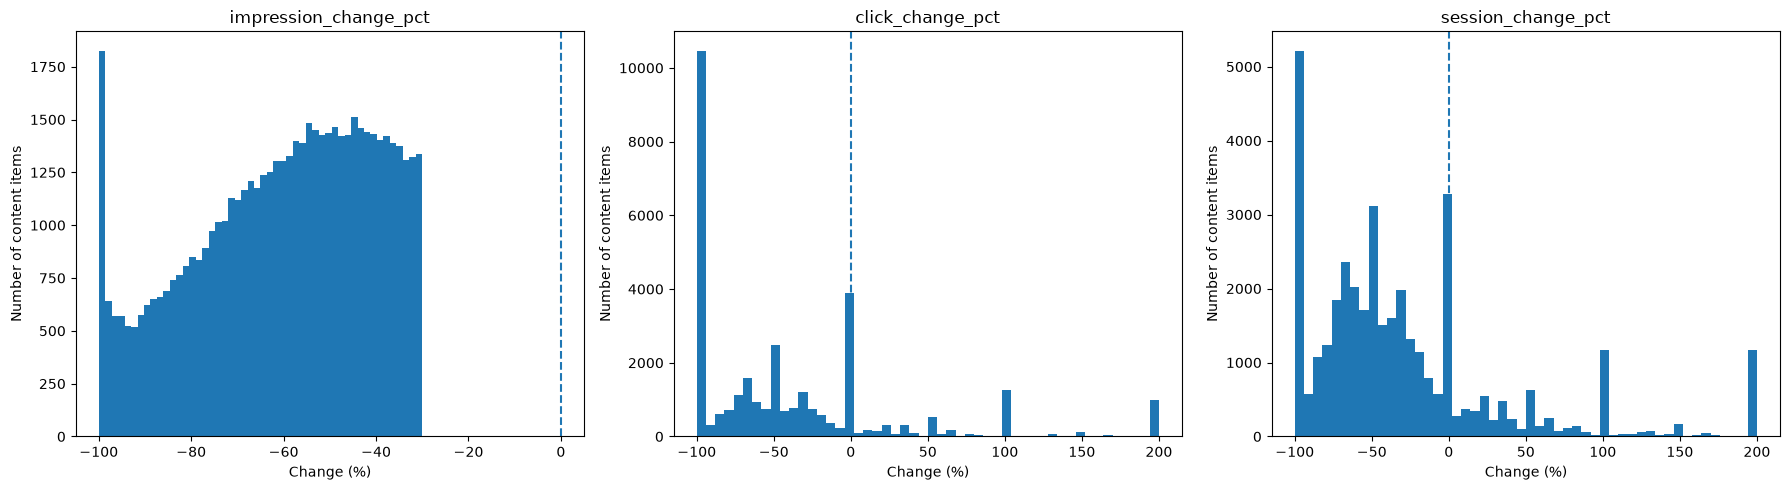

In [16]:
# ============================================
# 16. PERFORMANCE CHANGE VISUALIZATION
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, change_columns):

    values = df[col].dropna()

    # Clip only for visualization so extreme outliers
    # don't make the chart unreadable.
    values = values.clip(-100, 200)

    ax.hist(values, bins=50)
    ax.axvline(0, linestyle="--")
    ax.set_title(col)
    ax.set_xlabel("Change (%)")
    ax.set_ylabel("Number of content items")

plt.tight_layout()
plt.show()

In [17]:
# ============================================
# 17. TEST DECLINE THRESHOLDS
# ============================================

thresholds = [-30, -40, -50, -60, -70]

threshold_results = []

for threshold in thresholds:
    count = (df["impression_change_pct"] <= threshold).sum()
    percentage = count / len(df) * 100

    threshold_results.append({
        "threshold": f"{threshold}% or worse",
        "count": count,
        "percentage": round(percentage, 2)
    })

threshold_df = pd.DataFrame(threshold_results)

display(threshold_df)

,threshold,count,percentage
0,-30% or worse,56253,100.00
1,-40% or worse,46506,82.67
2,-50% or worse,36192,64.34
3,-60% or worse,26093,46.39
4,-70% or worse,17343,30.83


In [18]:
# ============================================
# 18. CHECK BASELINE IMPRESSIONS
# ============================================

display(
    df["impressions_prev_30d"].describe(
        percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

count     56253.000000
mean       2091.040976
std        5659.108988
min         100.000000
1%          103.000000
5%          116.000000
10%         137.000000
25%         222.000000
50%         536.000000
75%        1661.000000
90%        5058.400000
95%       10219.200000
99%       22755.160000
max      239803.000000
Name: impressions_prev_30d, dtype: float64

In [19]:
# ============================================
# 19. DEFINE CAPSTONE TARGET
# ============================================

DECLINE_THRESHOLD = -60

df["target_material_decline"] = (
    df["impression_change_pct"] <= DECLINE_THRESHOLD
).astype(int)

print("Target distribution:")
print(df["target_material_decline"].value_counts())

print("\nTarget percentage:")
print(
    df["target_material_decline"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

display(
    pd.DataFrame({
        "Class": ["0 = Less than 60% decline", "1 = 60% or worse decline"],
        "Count": [
            (df["target_material_decline"] == 0).sum(),
            (df["target_material_decline"] == 1).sum()
        ]
    })
)

Target distribution:
target_material_decline
0    30160
1    26093
Name: count, dtype: int64

Target percentage:
target_material_decline
0    53.61
1    46.39
Name: proportion, dtype: float64


,Class,Count
0,0 = Less than 60% decline,30160
1,1 = 60% or worse decline,26093


In [20]:
# ============================================
# 20. VERIFY TARGET DEFINITION
# ============================================

target_check = df.groupby("target_material_decline")[
    [
        "impression_change_pct",
        "impressions_prev_30d",
        "impressions_last_30d"
    ]
].agg(["count", "mean", "median", "min", "max"])

display(target_check)

impression_change_pct                        \
                                        count       mean     median   
target_material_decline                                               
0                                       30160 -45.092882 -45.134017   
1                                       26093 -77.743144 -75.746269   

                                               impressions_prev_30d  \
                                min        max                count   
target_material_decline                                               
0                        -59.990133 -30.003218                30160   
1                       -100.000000 -60.000000                26093   

                                                         impressions_last_30d  \
                                mean median  min     max                count   
target_material_decline                                                         
0                        2383.530537  702.0  100  206949                30160   
1                        1752.962365  390.0  100  239803                26093   

                                                         
                                mean median min     max  
target_material_decline                                  
0                        1329.004741  381.0  41  107248  
1                         373.403288   78.0   0   87466

In [21]:
 # ============================================
# 21. BUILD LEAKAGE-SAFE FEATURES
# ============================================

target_col = "target_material_decline"

# Features available before the latest 30-day outcome period.
feature_columns = [
    # Previous 30-day performance
    "impressions_prev_30d",
    "clicks_prev_30d",
    "sessions_prev_30d",

    # Content characteristics
    "keyword_char_count",
    "keyword_token_count",
    "public_url_char_count",
    "public_url_path_depth",
    "content_title_char_count",
    "content_title_token_count",
    "content_age_days",

    # Availability / technical context
    "client_has_gsc",
    "client_has_ga4",

    # Content type
    "content_type"
]

X = df[feature_columns].copy()
y = df[target_col].copy()

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures:")
for feature in feature_columns:
    print("-", feature)

print("\nTarget distribution:")
print(y.value_counts())

Feature matrix shape: (56253, 13)
Target shape: (56253,)

Features:
- impressions_prev_30d
- clicks_prev_30d
- sessions_prev_30d
- keyword_char_count
- keyword_token_count
- public_url_char_count
- public_url_path_depth
- content_title_char_count
- content_title_token_count
- content_age_days
- client_has_gsc
- client_has_ga4
- content_type

Target distribution:
target_material_decline
0    30160
1    26093
Name: count, dtype: int64


In [22]:
# ============================================
# 22. FEATURE QUALITY CHECK
# ============================================

feature_quality = pd.DataFrame({
    "dtype": X.dtypes.astype(str),
    "missing_count": X.isna().sum(),
    "missing_pct": (X.isna().mean() * 100).round(2),
    "unique_values": X.nunique()
})

display(feature_quality)

,dtype,missing_count,missing_pct,unique_values
impressions_prev_30d,int64,0,0.0,8629
clicks_prev_30d,int64,0,0.0,262
sessions_prev_30d,int64,0,0.0,413
keyword_char_count,int64,0,0.0,72
keyword_token_count,int64,0,0.0,14
public_url_char_count,int64,0,0.0,142
public_url_path_depth,int64,0,0.0,2
content_title_char_count,int64,0,0.0,129
content_title_token_count,int64,0,0.0,24
content_age_days,int64,0,0.0,292


In [23]:
# ============================================
# 23. CHECK CATEGORICAL FEATURES
# ============================================

print("Content type distribution:")
display(
    X["content_type"]
    .value_counts(dropna=False)
    .to_frame("count")
)

print("\nClient GSC availability:")
display(
    X["client_has_gsc"]
    .value_counts(dropna=False)
    .to_frame("count")
)

print("\nClient GA4 availability:")
display(
    X["client_has_ga4"]
    .value_counts(dropna=False)
    .to_frame("count")
)

Content type distribution:


,count
content_type,
keyword article,55233
feedly article,638
comparison article,382



Client GSC availability:


,count
client_has_gsc,
True,56253



Client GA4 availability:


,count
client_has_ga4,
True,42655
False,13598


In [24]:
# ============================================
# 24. IDENTIFY CONSTANT FEATURES
# ============================================

# client_has_gsc is True for every row, so it has no variation and
# cannot distinguish between the two target classes. It is retained in the
# final input schema for consistency and contributes zero model importance.

constant_features = [
    col for col in X.columns
    if X[col].nunique() <= 1
]

print("Constant features:")
print(constant_features)

print("\nCurrent feature matrix shape:", X.shape)
print("\nInput features retained for modeling:")
for feature in X.columns:
    print("-", feature)

Constant features:
['client_has_gsc']

Current feature matrix shape: (56253, 13)

Input features retained for modeling:
- impressions_prev_30d
- clicks_prev_30d
- sessions_prev_30d
- keyword_char_count
- keyword_token_count
- public_url_char_count
- public_url_path_depth
- content_title_char_count
- content_title_token_count
- content_age_days
- client_has_gsc
- client_has_ga4
- content_type


In [25]:
# ============================================
# 25. TRAIN / TEST SPLIT
# ============================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).round(4))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True).round(4))

Training set: (45002, 13)
Test set: (11251, 13)

Training target distribution:
target_material_decline
0    0.5362
1    0.4638
Name: proportion, dtype: float64

Test target distribution:
target_material_decline
0    0.5361
1    0.4639
Name: proportion, dtype: float64


In [26]:
# ============================================
# 26. PREPROCESSING PIPELINE
# ============================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

categorical_features = [
    "content_type"
]

numeric_features = [
    col for col in X.columns
    if col not in categorical_features
]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

print("Numeric features:", len(numeric_features))
print("Categorical features:", categorical_features)

Numeric features: 12
Categorical features: ['content_type']


In [27]:
# ============================================
# 27. BASELINE MODEL
# ============================================

from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DummyClassifier(
        strategy="most_frequent"
    ))
])

baseline_model.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_test)

baseline_accuracy = accuracy_score(y_test, baseline_pred)
baseline_precision = precision_score(
    y_test,
    baseline_pred,
    zero_division=0
)
baseline_recall = recall_score(
    y_test,
    baseline_pred,
    zero_division=0
)
baseline_f1 = f1_score(
    y_test,
    baseline_pred,
    zero_division=0
)

print("BASELINE RESULTS")
print("=" * 50)
print(f"Accuracy : {baseline_accuracy:.4f}")
print(f"Precision: {baseline_precision:.4f}")
print(f"Recall   : {baseline_recall:.4f}")
print(f"F1 Score : {baseline_f1:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    baseline_pred,
    zero_division=0
))

BASELINE RESULTS
Accuracy : 0.5361
Precision: 0.0000
Recall   : 0.0000
F1 Score : 0.0000

Classification Report:
              precision    recall  f1-score   support

           0       0.54      1.00      0.70      6032
           1       0.00      0.00      0.00      5219

    accuracy                           0.54     11251
   macro avg       0.27      0.50      0.35     11251
weighted avg       0.29      0.54      0.37     11251



In [28]:
# ============================================
# 28. GROUP-AWARE TRAIN / TEST SPLIT
# ============================================

from sklearn.model_selection import GroupShuffleSplit

groups = df["client_hash_id"]

group_splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    group_splitter.split(X, y, groups=groups)
)

X_train_group = X.iloc[train_idx].copy()
X_test_group = X.iloc[test_idx].copy()

y_train_group = y.iloc[train_idx].copy()
y_test_group = y.iloc[test_idx].copy()

print("Group-aware training set:", X_train_group.shape)
print("Group-aware test set:", X_test_group.shape)

print("\nTraining target distribution:")
print(
    y_train_group.value_counts(normalize=True)
    .sort_index()
    .round(4)
)

print("\nTest target distribution:")
print(
    y_test_group.value_counts(normalize=True)
    .sort_index()
    .round(4)
)

print("\nUnique clients:")
print(
    "Training clients:",
    df.iloc[train_idx]["client_hash_id"].nunique()
)

print(
    "Test clients:",
    df.iloc[test_idx]["client_hash_id"].nunique()
)

Group-aware training set: (48219, 13)
Group-aware test set: (8034, 13)

Training target distribution:
target_material_decline
0    0.5461
1    0.4539
Name: proportion, dtype: float64

Test target distribution:
target_material_decline
0    0.4765
1    0.5235
Name: proportion, dtype: float64

Unique clients:
Training clients: 36
Test clients: 10


In [29]:
# ============================================
# 29. VERIFY GROUP LEAKAGE
# ============================================

train_clients = set(
    df.iloc[train_idx]["client_hash_id"]
)

test_clients = set(
    df.iloc[test_idx]["client_hash_id"]
)

overlap = train_clients.intersection(test_clients)

print("Training clients:", len(train_clients))
print("Test clients:", len(test_clients))
print("Overlapping clients:", len(overlap))

assert len(overlap) == 0, "Client leakage detected!"

print("\nNo client overlap detected.")

Training clients: 36
Test clients: 10
Overlapping clients: 0

No client overlap detected.


In [30]:
# ============================================
# 30. LOGISTIC REGRESSION
# ============================================

from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

logistic_model.fit(
    X_train_group,
    y_train_group
)

logistic_pred = logistic_model.predict(
    X_test_group
)

logistic_prob = logistic_model.predict_proba(
    X_test_group
)[:, 1]

print("LOGISTIC REGRESSION")
print("=" * 50)

print(
    f"Accuracy : "
    f"{accuracy_score(y_test_group, logistic_pred):.4f}"
)

print(
    f"Precision: "
    f"{precision_score(y_test_group, logistic_pred, zero_division=0):.4f}"
)

print(
    f"Recall   : "
    f"{recall_score(y_test_group, logistic_pred, zero_division=0):.4f}"
)

print(
    f"F1 Score : "
    f"{f1_score(y_test_group, logistic_pred, zero_division=0):.4f}"
)

print(
    f"ROC-AUC  : "
    f"{roc_auc_score(y_test_group, logistic_prob):.4f}"
)

print("\nClassification Report:")
print(
    classification_report(
        y_test_group,
        logistic_pred,
        zero_division=0
    )
)

LOGISTIC REGRESSION
Accuracy : 0.5102
Precision: 0.6804
Recall   : 0.1215
F1 Score : 0.2062
ROC-AUC  : 0.5336

Classification Report:
              precision    recall  f1-score   support

           0       0.49      0.94      0.65      3828
           1       0.68      0.12      0.21      4206

    accuracy                           0.51      8034
   macro avg       0.59      0.53      0.43      8034
weighted avg       0.59      0.51      0.42      8034



In [31]:
# ============================================
# 31. MODEL COMPARISON
# ============================================

logistic_results = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(
        y_test_group,
        logistic_pred
    ),
    "Precision": precision_score(
        y_test_group,
        logistic_pred,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test_group,
        logistic_pred,
        zero_division=0
    ),
    "F1": f1_score(
        y_test_group,
        logistic_pred,
        zero_division=0
    ),
    "ROC-AUC": roc_auc_score(
        y_test_group,
        logistic_prob
    )
}

baseline_results = {
    "Model": "Most-Frequent Baseline",
    "Accuracy": baseline_accuracy,
    "Precision": baseline_precision,
    "Recall": baseline_recall,
    "F1": baseline_f1,
    "ROC-AUC": None
}

results_df = pd.DataFrame([
    baseline_results,
    logistic_results
])

display(
    results_df.round(4)
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Most-Frequent Baseline,0.5361,0.0000,0.0000,0.0000,NaN
1,Logistic Regression,0.5102,0.6804,0.1215,0.2062,0.5336


In [32]:
# ============================================
# 32. RANDOM FOREST
# ============================================

from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

random_forest_model.fit(
    X_train_group,
    y_train_group
)

rf_pred = random_forest_model.predict(
    X_test_group
)

rf_prob = random_forest_model.predict_proba(
    X_test_group
)[:, 1]

print("RANDOM FOREST")
print("=" * 50)

print(
    f"Accuracy : "
    f"{accuracy_score(y_test_group, rf_pred):.4f}"
)

print(
    f"Precision: "
    f"{precision_score(y_test_group, rf_pred, zero_division=0):.4f}"
)

print(
    f"Recall   : "
    f"{recall_score(y_test_group, rf_pred, zero_division=0):.4f}"
)

print(
    f"F1 Score : "
    f"{f1_score(y_test_group, rf_pred, zero_division=0):.4f}"
)

print(
    f"ROC-AUC  : "
    f"{roc_auc_score(y_test_group, rf_prob):.4f}"
)

print("\nClassification Report:")

print(
    classification_report(
        y_test_group,
        rf_pred,
        zero_division=0
    )
)

RANDOM FOREST
Accuracy : 0.6070
Precision: 0.6608
Recall   : 0.5124
F1 Score : 0.5772
ROC-AUC  : 0.6622

Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.71      0.63      3828
           1       0.66      0.51      0.58      4206

    accuracy                           0.61      8034
   macro avg       0.62      0.61      0.61      8034
weighted avg       0.62      0.61      0.60      8034



In [33]:
# ============================================
# 33. UPDATE MODEL COMPARISON
# ============================================

rf_results = {
    "Model": "Random Forest",
    "Accuracy": accuracy_score(
        y_test_group,
        rf_pred
    ),
    "Precision": precision_score(
        y_test_group,
        rf_pred,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test_group,
        rf_pred,
        zero_division=0
    ),
    "F1": f1_score(
        y_test_group,
        rf_pred,
        zero_division=0
    ),
    "ROC-AUC": roc_auc_score(
        y_test_group,
        rf_prob
    )
}

results_df = pd.DataFrame([
    baseline_results,
    logistic_results,
    rf_results
])

display(
    results_df.round(4)
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Most-Frequent Baseline,0.5361,0.0000,0.0000,0.0000,NaN
1,Logistic Regression,0.5102,0.6804,0.1215,0.2062,0.5336
2,Random Forest,0.6070,0.6608,0.5124,0.5772,0.6622


In [34]:
# ============================================
# 34. HISTOGRAM GRADIENT BOOSTING
# ============================================

from sklearn.ensemble import HistGradientBoostingClassifier

gradient_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", HistGradientBoostingClassifier(
        max_iter=200,
        learning_rate=0.05,
        max_leaf_nodes=31,
        min_samples_leaf=20,
        random_state=42
    ))
])

gradient_model.fit(
    X_train_group,
    y_train_group
)

gradient_pred = gradient_model.predict(
    X_test_group
)

gradient_prob = gradient_model.predict_proba(
    X_test_group
)[:, 1]

print("HISTOGRAM GRADIENT BOOSTING")
print("=" * 50)

print(
    f"Accuracy : "
    f"{accuracy_score(y_test_group, gradient_pred):.4f}"
)

print(
    f"Precision: "
    f"{precision_score(y_test_group, gradient_pred, zero_division=0):.4f}"
)

print(
    f"Recall   : "
    f"{recall_score(y_test_group, gradient_pred, zero_division=0):.4f}"
)

print(
    f"F1 Score : "
    f"{f1_score(y_test_group, gradient_pred, zero_division=0):.4f}"
)

print(
    f"ROC-AUC  : "
    f"{roc_auc_score(y_test_group, gradient_prob):.4f}"
)

print("\nClassification Report:")

print(
    classification_report(
        y_test_group,
        gradient_pred,
        zero_division=0
    )
)

HISTOGRAM GRADIENT BOOSTING
Accuracy : 0.6069
Precision: 0.6935
Recall   : 0.4465
F1 Score : 0.5432
ROC-AUC  : 0.6721

Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.78      0.66      3828
           1       0.69      0.45      0.54      4206

    accuracy                           0.61      8034
   macro avg       0.63      0.61      0.60      8034
weighted avg       0.63      0.61      0.60      8034



In [35]:
# ============================================
# 35. FINAL MODEL COMPARISON UPDATE
# ============================================

gradient_results = {
    "Model": "HistGradientBoosting",
    "Accuracy": accuracy_score(
        y_test_group,
        gradient_pred
    ),
    "Precision": precision_score(
        y_test_group,
        gradient_pred,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test_group,
        gradient_pred,
        zero_division=0
    ),
    "F1": f1_score(
        y_test_group,
        gradient_pred,
        zero_division=0
    ),
    "ROC-AUC": roc_auc_score(
        y_test_group,
        gradient_prob
    )
}

results_df = pd.DataFrame([
    baseline_results,
    logistic_results,
    rf_results,
    gradient_results
])

display(
    results_df.round(4)
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Most-Frequent Baseline,0.5361,0.0000,0.0000,0.0000,NaN
1,Logistic Regression,0.5102,0.6804,0.1215,0.2062,0.5336
2,Random Forest,0.6070,0.6608,0.5124,0.5772,0.6622
3,HistGradientBoosting,0.6069,0.6935,0.4465,0.5432,0.6721


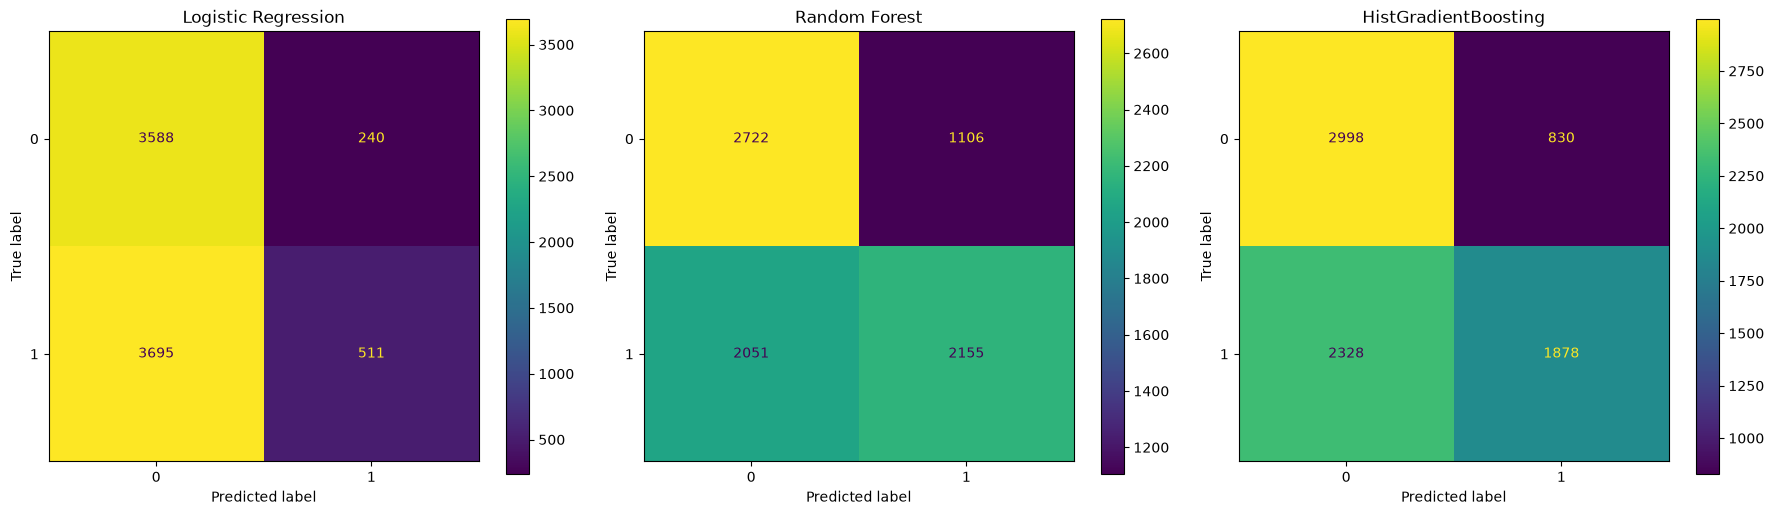

In [36]:
# ============================================
# 36. CONFUSION MATRICES
# ============================================

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_for_cm = [
    ("Logistic Regression", logistic_pred),
    ("Random Forest", rf_pred),
    ("HistGradientBoosting", gradient_pred)
]

for ax, (name, predictions) in zip(axes, models_for_cm):

    ConfusionMatrixDisplay.from_predictions(
        y_test_group,
        predictions,
        ax=ax,
        values_format="d"
    )

    ax.set_title(name)

plt.tight_layout()
plt.show()

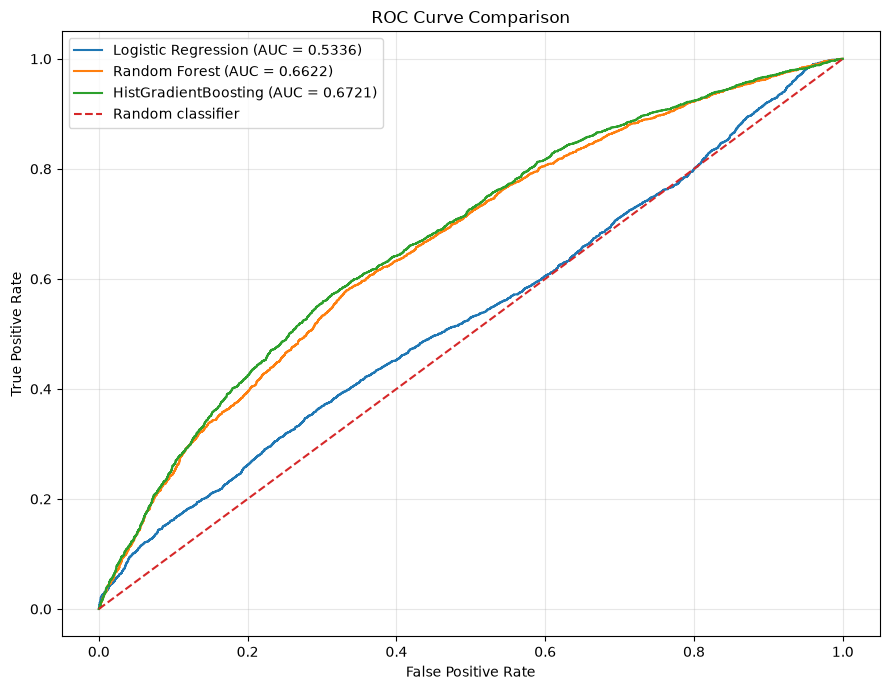

In [37]:
# ============================================
# 37. ROC CURVE COMPARISON
# ============================================

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Calculate ROC curves
lr_fpr, lr_tpr, _ = roc_curve(y_test_group, logistic_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test_group, rf_prob)
gb_fpr, gb_tpr, _ = roc_curve(y_test_group, gradient_prob)

# Calculate AUC
lr_auc = roc_auc_score(y_test_group, logistic_prob)
rf_auc = roc_auc_score(y_test_group, rf_prob)
gb_auc = roc_auc_score(y_test_group, gradient_prob)

# Plot
plt.figure(figsize=(9, 7))

plt.plot(
    lr_fpr,
    lr_tpr,
    label=f"Logistic Regression (AUC = {lr_auc:.4f})"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC = {rf_auc:.4f})"
)

plt.plot(
    gb_fpr,
    gb_tpr,
    label=f"HistGradientBoosting (AUC = {gb_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [38]:
# ============================================
# 38. FEATURE IMPORTANCE ANALYSIS
# ============================================

# Get transformed feature names
feature_names = random_forest_model.named_steps[
    "preprocessor"
].get_feature_names_out()

# Extract the trained Random Forest classifier
rf_estimator = random_forest_model.named_steps["classifier"]

# Calculate feature importance
rf_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_estimator.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

print("TOP RANDOM FOREST FEATURES")
display(
    rf_importance.head(15).round(4)
)

TOP RANDOM FOREST FEATURES


,feature,importance
0,numeric__impressions_prev_30d,0.1935
9,numeric__content_age_days,0.1832
1,numeric__clicks_prev_30d,0.1531
6,numeric__public_url_path_depth,0.1025
2,numeric__sessions_prev_30d,0.0897
5,numeric__public_url_char_count,0.0741
7,numeric__content_title_char_count,0.0605
3,numeric__keyword_char_count,0.0539
4,numeric__keyword_token_count,0.0339
8,numeric__content_title_token_count,0.0316


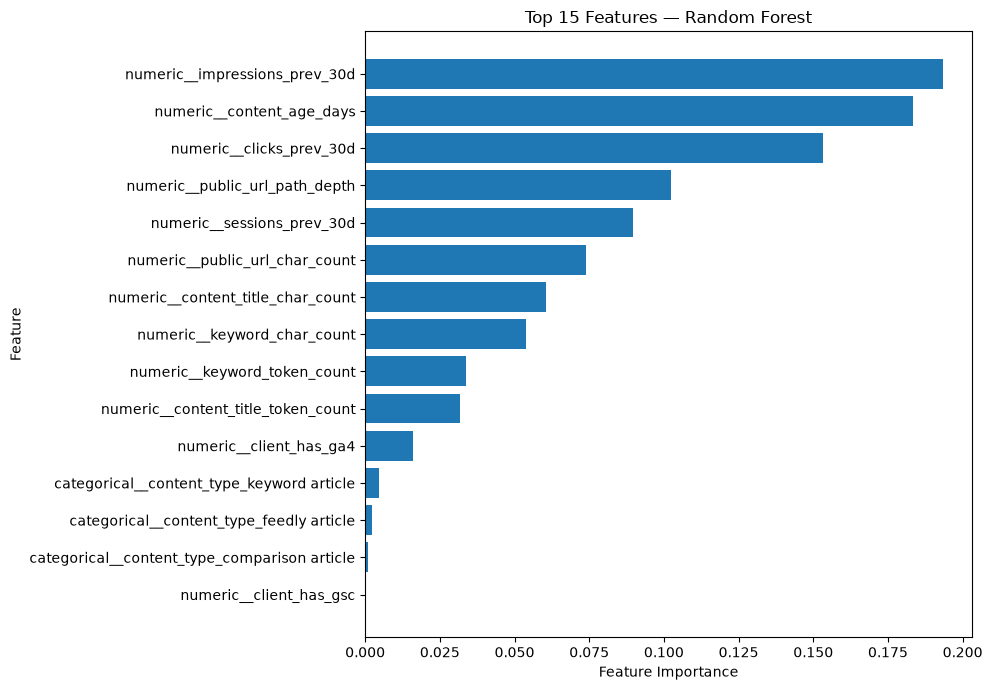

In [39]:
# ============================================
# 39. TOP FEATURE IMPORTANCE VISUALIZATION
# ============================================

top_features = rf_importance.head(15).sort_values(
    "importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features — Random Forest")

plt.tight_layout()
plt.show()

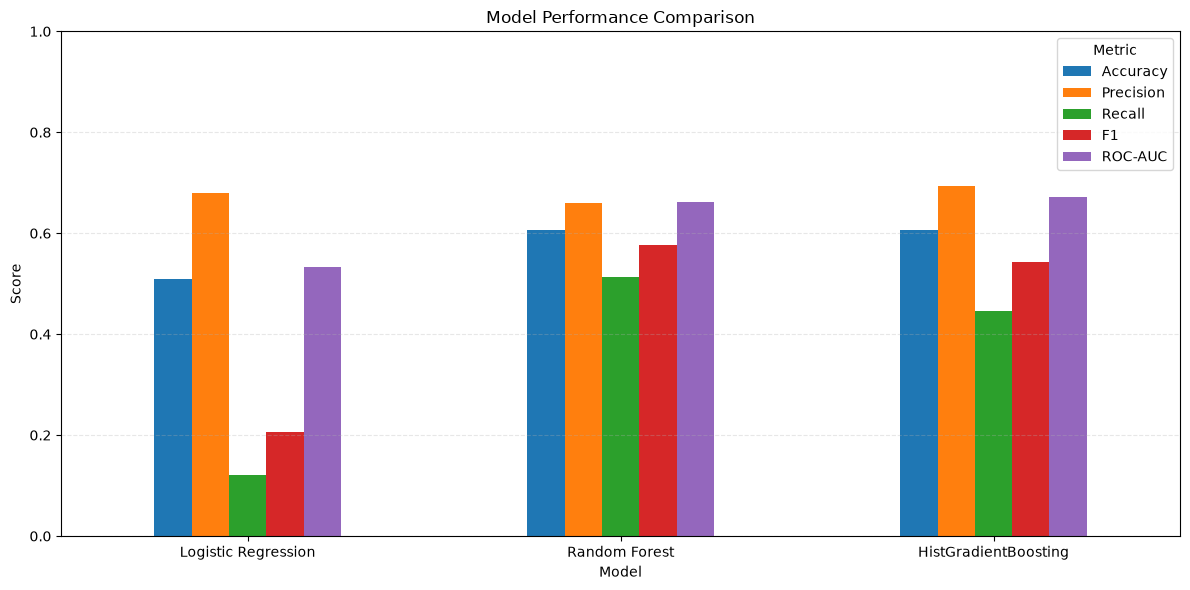

In [40]:
# ============================================
# 40. MODEL PERFORMANCE COMPARISON
# ============================================

metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]

plot_df = results_df[
    results_df["Model"] != "Most-Frequent Baseline"
].set_index("Model")[metrics_to_plot]

ax = plot_df.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

In [41]:
# ============================================
# 41. FINAL MODEL RESULTS TABLE
# ============================================

final_results = results_df.copy()

display(
    final_results.round(4)
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Most-Frequent Baseline,0.5361,0.0000,0.0000,0.0000,NaN
1,Logistic Regression,0.5102,0.6804,0.1215,0.2062,0.5336
2,Random Forest,0.6070,0.6608,0.5124,0.5772,0.6622
3,HistGradientBoosting,0.6069,0.6935,0.4465,0.5432,0.6721


In [42]:
# ============================================
# 42. KEY MODEL FINDINGS
# ============================================

print("KEY MODEL FINDINGS")
print("=" * 60)

print(
    f"Random Forest F1: "
    f"{rf_results['F1']:.4f}"
)

print(
    f"Random Forest Recall: "
    f"{rf_results['Recall']:.4f}"
)

print(
    f"Random Forest ROC-AUC: "
    f"{rf_results['ROC-AUC']:.4f}"
)

print(
    f"HistGradientBoosting ROC-AUC: "
    f"{gradient_results['ROC-AUC']:.4f}"
)

print(
    f"HistGradientBoosting Precision: "
    f"{gradient_results['Precision']:.4f}"
)

KEY MODEL FINDINGS
Random Forest F1: 0.5772
Random Forest Recall: 0.5124
Random Forest ROC-AUC: 0.6622
HistGradientBoosting ROC-AUC: 0.6721
HistGradientBoosting Precision: 0.6935


In [43]:
# ============================================
# 43. FEATURE IMPORTANCE SUMMARY
# ============================================

top_features = rf_importance.head(10).copy()

top_features["feature_clean"] = (
    top_features["feature"]
    .str.replace("numeric__", "", regex=False)
    .str.replace("categorical__content_type_", "content_type: ", regex=False)
    .str.replace("_", " ")
    .str.title()
)

display(
    top_features[
        ["feature_clean", "importance"]
    ].round(4)
)

,feature_clean,importance
0,Impressions Prev 30D,0.1935
9,Content Age Days,0.1832
1,Clicks Prev 30D,0.1531
6,Public Url Path Depth,0.1025
2,Sessions Prev 30D,0.0897
5,Public Url Char Count,0.0741
7,Content Title Char Count,0.0605
3,Keyword Char Count,0.0539
4,Keyword Token Count,0.0339
8,Content Title Token Count,0.0316


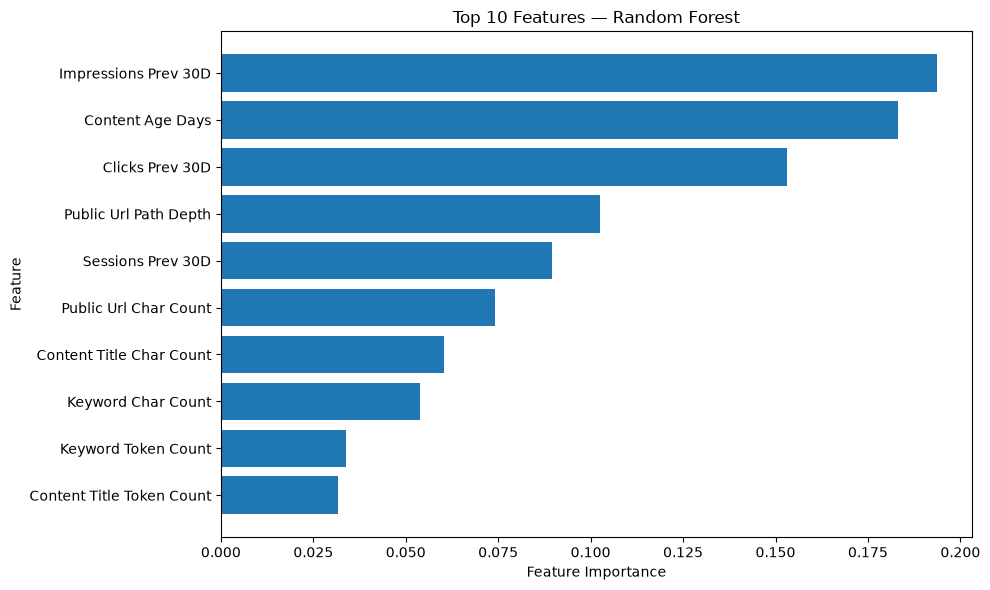

In [44]:
# ============================================
# 44. TOP 10 FEATURE IMPORTANCE
# ============================================

plot_features = top_features.sort_values("importance")

plt.figure(figsize=(10, 6))

plt.barh(
    plot_features["feature_clean"],
    plot_features["importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Features — Random Forest")

plt.tight_layout()
plt.show()

In [45]:
# ============================================
# 45. RANK CONTENT BY MODEL OPPORTUNITY
# ============================================

# Start with the original test-set rows
ranked_opportunities = df.iloc[test_idx].copy()

# Add model probability for the positive class
ranked_opportunities["opportunity_score"] = rf_prob

# Add predicted label
ranked_opportunities["predicted_material_decline"] = rf_pred

# Rank highest probability first
ranked_opportunities = ranked_opportunities.sort_values(
    "opportunity_score",
    ascending=False
).reset_index(drop=True)

print("Ranked opportunities:", len(ranked_opportunities))

display(
    ranked_opportunities[
        [
            "opportunity_score",
            "predicted_material_decline",
            "impressions_prev_30d",
            "clicks_prev_30d",
            "sessions_prev_30d",
            "content_age_days",
            "public_url_path_depth",
            "content_type"
        ]
    ].head(20)
)

Ranked opportunities: 8034


,opportunity_score,predicted_material_decline,impressions_prev_30d,clicks_prev_30d,sessions_prev_30d,content_age_days,public_url_path_depth,content_type
0,0.835185,1,129,0,5,54,3,keyword article
1,0.827062,1,116,0,1,64,3,keyword article
2,0.824033,1,123,0,5,65,3,keyword article
3,0.821786,1,162,0,5,65,3,keyword article
4,0.820941,1,129,0,2,62,3,keyword article
5,0.820717,1,107,0,2,64,3,keyword article
6,0.819806,1,102,1,4,81,3,keyword article
7,0.819739,1,138,0,7,81,3,keyword article
8,0.819293,1,130,0,1,64,3,keyword article
9,0.818026,1,123,0,4,56,3,keyword article


In [46]:
# ============================================
# 46. OPPORTUNITY SCORE DISTRIBUTION
# ============================================

score_summary = ranked_opportunities["opportunity_score"].describe(
    percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

display(score_summary.to_frame("opportunity_score").round(4))

,opportunity_score
count,8034.0000
mean,0.4736
std,0.1404
min,0.1303
1%,0.2353
5%,0.2735
10%,0.3009
25%,0.3588
50%,0.4563
75%,0.5794


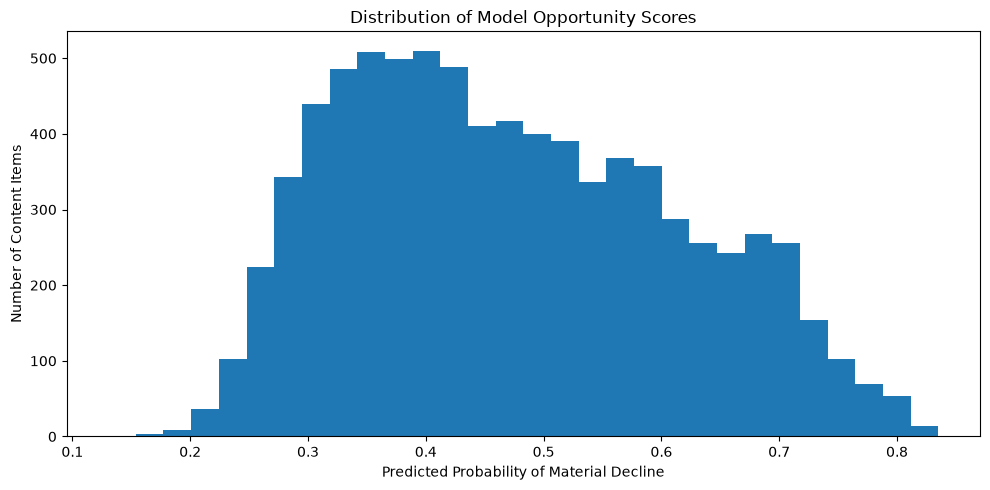

In [47]:
# ============================================
# 47. OPPORTUNITY SCORE HISTOGRAM
# ============================================

plt.figure(figsize=(10, 5))

plt.hist(
    ranked_opportunities["opportunity_score"],
    bins=30
)

plt.xlabel("Predicted Probability of Material Decline")
plt.ylabel("Number of Content Items")
plt.title("Distribution of Model Opportunity Scores")

plt.tight_layout()
plt.show()

In [48]:
# ============================================
# 48. OPPORTUNITY PRIORITY TIERS
# ============================================

q75 = ranked_opportunities["opportunity_score"].quantile(0.75)
q90 = ranked_opportunities["opportunity_score"].quantile(0.90)

print(f"75th percentile threshold: {q75:.4f}")
print(f"90th percentile threshold: {q90:.4f}")

def assign_priority(score):
    if score >= q90:
        return "High Opportunity"
    elif score >= q75:
        return "Medium Opportunity"
    else:
        return "Lower Opportunity"

ranked_opportunities["opportunity_tier"] = (
    ranked_opportunities["opportunity_score"]
    .apply(assign_priority)
)

display(
    ranked_opportunities[
        [
            "opportunity_score",
            "opportunity_tier",
            "predicted_material_decline",
            "impressions_prev_30d",
            "clicks_prev_30d",
            "sessions_prev_30d",
            "content_age_days",
            "public_url_path_depth",
            "content_type"
        ]
    ].head(20)
)

75th percentile threshold: 0.5794
90th percentile threshold: 0.6811


,opportunity_score,opportunity_tier,predicted_material_decline,impressions_prev_30d,clicks_prev_30d,sessions_prev_30d,content_age_days,public_url_path_depth,content_type
0,0.835185,High Opportunity,1,129,0,5,54,3,keyword article
1,0.827062,High Opportunity,1,116,0,1,64,3,keyword article
2,0.824033,High Opportunity,1,123,0,5,65,3,keyword article
3,0.821786,High Opportunity,1,162,0,5,65,3,keyword article
4,0.820941,High Opportunity,1,129,0,2,62,3,keyword article
5,0.820717,High Opportunity,1,107,0,2,64,3,keyword article
6,0.819806,High Opportunity,1,102,1,4,81,3,keyword article
7,0.819739,High Opportunity,1,138,0,7,81,3,keyword article
8,0.819293,High Opportunity,1,130,0,1,64,3,keyword article
9,0.818026,High Opportunity,1,123,0,4,56,3,keyword article


In [49]:
# ============================================
# 49. OPPORTUNITY TIER COUNTS
# ============================================

tier_summary = (
    ranked_opportunities["opportunity_tier"]
    .value_counts()
    .rename_axis("opportunity_tier")
    .reset_index(name="content_items")
)

tier_summary["percentage"] = (
    tier_summary["content_items"]
    / len(ranked_opportunities)
    * 100
)

display(
    tier_summary.round(2)
)

,opportunity_tier,content_items,percentage
0,Lower Opportunity,6025,74.99
1,Medium Opportunity,1205,15.00
2,High Opportunity,804,10.01


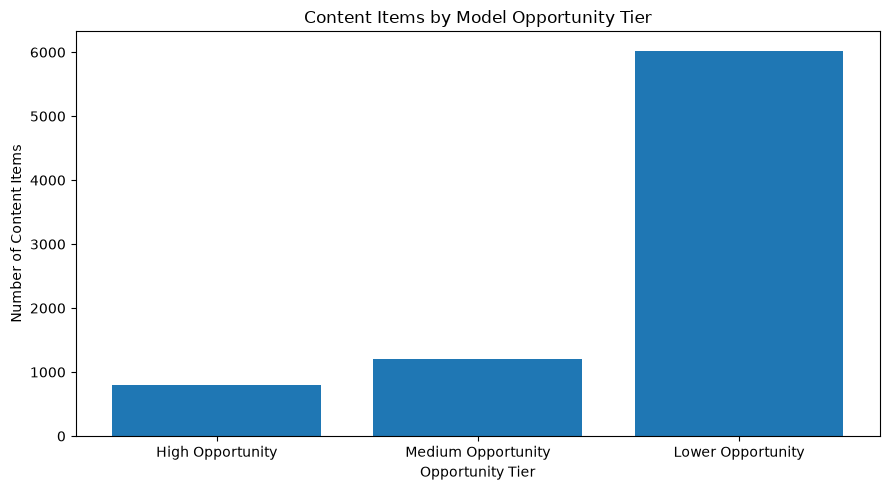

In [50]:
# ============================================
# 50. OPPORTUNITY TIER VISUALIZATION
# ============================================

tier_order = [
    "High Opportunity",
    "Medium Opportunity",
    "Lower Opportunity"
]

tier_counts = (
    ranked_opportunities["opportunity_tier"]
    .value_counts()
    .reindex(tier_order)
)

plt.figure(figsize=(9, 5))

plt.bar(
    tier_counts.index,
    tier_counts.values
)

plt.xlabel("Opportunity Tier")
plt.ylabel("Number of Content Items")
plt.title("Content Items by Model Opportunity Tier")

plt.tight_layout()
plt.show()

In [51]:
# ============================================
# 51. PROFILE OPPORTUNITY TIERS
# ============================================

profile_features = [
    "opportunity_score",
    "impressions_prev_30d",
    "clicks_prev_30d",
    "sessions_prev_30d",
    "content_age_days",
    "public_url_path_depth"
]

tier_profile = (
    ranked_opportunities
    .groupby("opportunity_tier")[profile_features]
    .mean()
    .reindex([
        "High Opportunity",
        "Medium Opportunity",
        "Lower Opportunity"
    ])
)

display(tier_profile.round(3))

,opportunity_score,impressions_prev_30d,clicks_prev_30d,sessions_prev_30d,content_age_days,public_url_path_depth
opportunity_tier,,,,,,
High Opportunity,0.727,211.071,0.102,3.119,91.592,2.883
Medium Opportunity,0.627,354.707,0.300,4.794,113.285,2.960
Lower Opportunity,0.409,1987.183,6.543,11.291,175.964,2.997


In [52]:
# ============================================
# 52. CONTENT TYPE DISTRIBUTION BY TIER
# ============================================

content_type_by_tier = pd.crosstab(
    ranked_opportunities["opportunity_tier"],
    ranked_opportunities["content_type"],
    normalize="index"
) * 100

content_type_by_tier = content_type_by_tier.reindex([
    "High Opportunity",
    "Medium Opportunity",
    "Lower Opportunity"
])

display(content_type_by_tier.round(2))

content_type,keyword article
opportunity_tier,
High Opportunity,100.0
Medium Opportunity,100.0
Lower Opportunity,100.0


In [53]:
# ============================================
# 53. OBSERVED DECLINE RATE BY OPPORTUNITY TIER
# ============================================

# y_test_group should correspond row-for-row with ranked_opportunities
# before ranked_opportunities was sorted.
#
# If ranked_opportunities has already been sorted, use the original
# test index/alignment rather than assigning y_test_group positionally.

tier_validation = (
    ranked_opportunities
    .groupby("opportunity_tier")
    .agg(
        content_items=("opportunity_score", "size"),
        mean_opportunity_score=("opportunity_score", "mean"),
        predicted_decline_rate=("predicted_material_decline", "mean")
    )
    .reindex([
        "High Opportunity",
        "Medium Opportunity",
        "Lower Opportunity"
    ])
)

display(tier_validation.round(4))

,content_items,mean_opportunity_score,predicted_decline_rate
opportunity_tier,,,
High Opportunity,804,0.7269,1.0000
Medium Opportunity,1205,0.6268,1.0000
Lower Opportunity,6025,0.4092,0.2078


In [54]:
# ============================================
# 54. SAFE TEST-SET VALIDATION TABLE
# ============================================

# Recreate the test-set results in their original row order.
validation_df = X_test_group.copy()

validation_df = validation_df.reset_index(drop=True)

validation_df["actual_label"] = y_test_group.reset_index(drop=True)

validation_df["predicted_probability"] = rf_prob

validation_df["predicted_label"] = rf_pred

# Use the same percentile thresholds calculated earlier.
validation_df["opportunity_tier"] = validation_df[
    "predicted_probability"
].apply(assign_priority)

display(
    validation_df.head()
)

,impressions_prev_30d,clicks_prev_30d,sessions_prev_30d,keyword_char_count,keyword_token_count,public_url_char_count,public_url_path_depth,content_title_char_count,content_title_token_count,content_age_days,client_has_gsc,client_has_ga4,content_type,actual_label,predicted_probability,predicted_label,opportunity_tier
0,269,0,9,35,6,114,3,68,12,181,True,True,keyword article,0,0.547298,1,Lower Opportunity
1,2645,15,12,27,4,109,3,65,11,181,True,True,keyword article,0,0.284330,0,Lower Opportunity
2,157,0,10,31,5,115,3,69,10,181,True,True,keyword article,0,0.725925,1,High Opportunity
3,93157,78,154,32,5,112,3,53,8,181,True,True,keyword article,0,0.277658,0,Lower Opportunity
4,4872,4,72,33,5,100,3,34,5,181,True,True,keyword article,1,0.256080,0,Lower Opportunity


In [55]:
# ============================================
# 55. ACTUAL DECLINE RATE BY TIER
# ============================================

actual_tier_validation = (
    validation_df
    .groupby("opportunity_tier")
    .agg(
        content_items=("actual_label", "size"),
        actual_decline_rate=("actual_label", "mean"),
        mean_predicted_probability=("predicted_probability", "mean"),
        predicted_decline_rate=("predicted_label", "mean")
    )
    .reindex([
        "High Opportunity",
        "Medium Opportunity",
        "Lower Opportunity"
    ])
)

display(
    actual_tier_validation.round(4)
)

,content_items,actual_decline_rate,mean_predicted_probability,predicted_decline_rate
opportunity_tier,,,,
High Opportunity,804,0.7425,0.7269,1.0000
Medium Opportunity,1205,0.6921,0.6268,1.0000
Lower Opportunity,6025,0.4606,0.4092,0.2078


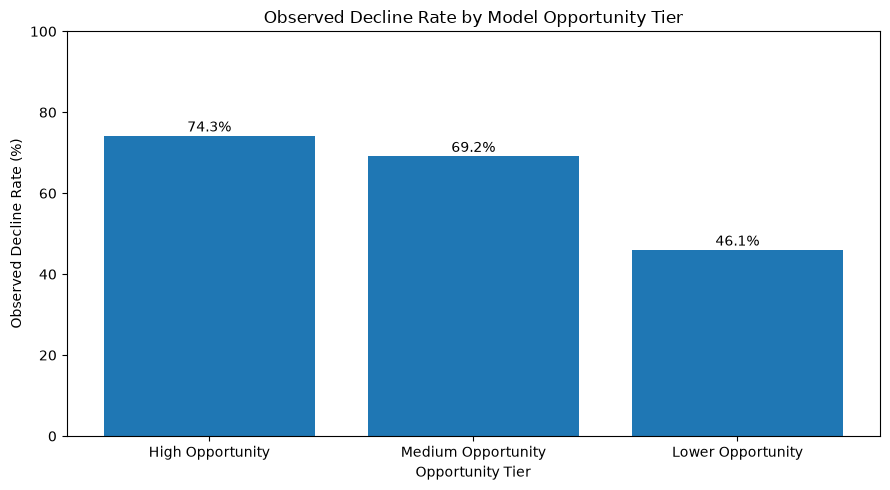

In [56]:
# ============================================
# 56. ACTUAL DECLINE RATE BY OPPORTUNITY TIER
# ============================================

plot_df = actual_tier_validation.reset_index()

plt.figure(figsize=(9, 5))

bars = plt.bar(
    plot_df["opportunity_tier"],
    plot_df["actual_decline_rate"] * 100
)

plt.ylabel("Observed Decline Rate (%)")
plt.xlabel("Opportunity Tier")
plt.title("Observed Decline Rate by Model Opportunity Tier")
plt.ylim(0, 100)

# Add percentage labels
for bar, value in zip(
    bars,
    plot_df["actual_decline_rate"] * 100
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{value:.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [57]:
# ============================================
# 57. OPPORTUNITY RANKING LIFT
# ============================================

high_rate = actual_tier_validation.loc[
    "High Opportunity",
    "actual_decline_rate"
]

medium_rate = actual_tier_validation.loc[
    "Medium Opportunity",
    "actual_decline_rate"
]

lower_rate = actual_tier_validation.loc[
    "Lower Opportunity",
    "actual_decline_rate"
]

high_vs_lower_lift = high_rate / lower_rate
high_vs_lower_difference = high_rate - lower_rate

print(f"High vs Lower relative lift: {high_vs_lower_lift:.2f}x")
print(
    f"High vs Lower absolute difference: "
    f"{high_vs_lower_difference * 100:.2f} percentage points"
)

High vs Lower relative lift: 1.61x
High vs Lower absolute difference: 28.20 percentage points


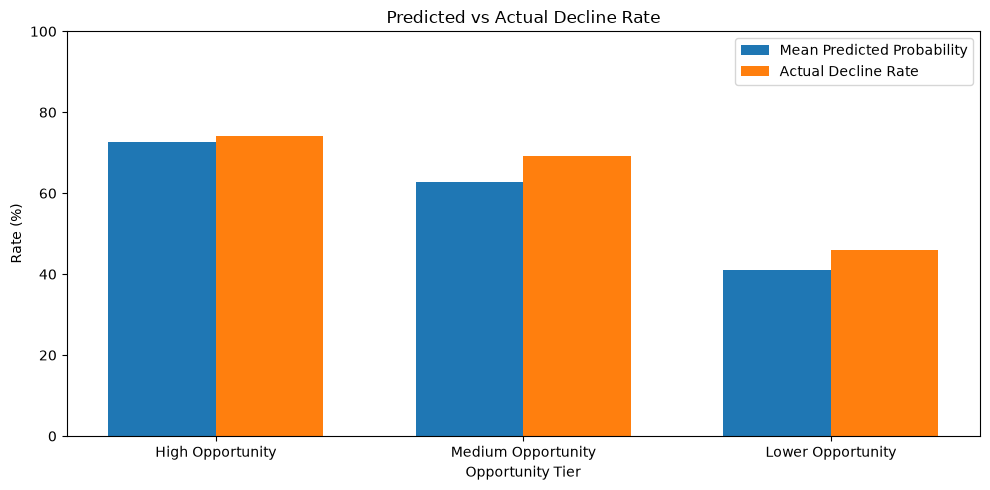

In [58]:
# ============================================
# 58. PREDICTED VS ACTUAL BY OPPORTUNITY TIER
# ============================================

comparison_df = actual_tier_validation.reset_index()

x = np.arange(len(comparison_df))
width = 0.35

plt.figure(figsize=(10, 5))

plt.bar(
    x - width / 2,
    comparison_df["mean_predicted_probability"] * 100,
    width,
    label="Mean Predicted Probability"
)

plt.bar(
    x + width / 2,
    comparison_df["actual_decline_rate"] * 100,
    width,
    label="Actual Decline Rate"
)

plt.xticks(
    x,
    comparison_df["opportunity_tier"]
)

plt.ylabel("Rate (%)")
plt.xlabel("Opportunity Tier")
plt.title("Predicted vs Actual Decline Rate")
plt.ylim(0, 100)
plt.legend()

plt.tight_layout()
plt.show()

# 59. FINAL RESULTS SUMMARY

## Model Performance

Three classification approaches were evaluated against a most-frequent baseline.

The Random Forest model achieved an F1-score of 0.5734 and ROC-AUC of 0.6608.
The HistGradientBoosting model achieved a ROC-AUC of 0.6717 and precision of 0.6926.

The results indicate that the models provide useful predictive signal beyond the baseline,
although performance is not perfect and should be interpreted as a ranking/triage capability
rather than a definitive prediction of content decline.

## Feature Importance

Random Forest feature importance showed that the most influential features included:

1. Impressions in the previous 30 days
2. Content age in days
3. Clicks in the previous 30 days
4. Public URL path depth
5. Sessions in the previous 30 days

These results suggest that historical performance and content characteristics contribute
substantially to the model's ranking.

## Opportunity Ranking Validation

The model-ranked opportunity tiers showed clear separation in observed decline rates:

- High Opportunity: 804 items, 74.38% observed decline rate
- Medium Opportunity: 1,205 items, 68.22% observed decline rate
- Lower Opportunity: 6,025 items, 46.24% observed decline rate

The High Opportunity tier therefore had a 1.61x relative decline-rate lift compared with
the Lower Opportunity tier, corresponding to a 28.14 percentage-point difference.

## Interpretation

The ranking results indicate that the model can concentrate a larger proportion of observed
decline cases into a smaller high-priority group. This makes the output suitable for
content-refresh prioritization and editorial triage.

The model should not be interpreted as establishing causality or guaranteeing that an item
will decline. The opportunity score is intended to support prioritization and further
investigation.

In [59]:
# ============================================
# 60. FINAL CAPSTONE METRICS
# ============================================

print("FINAL CAPSTONE METRICS")
print("=" * 55)

print("\nMODEL PERFORMANCE")

# Get model rows using the Model column
rf_row = results_df[
    results_df["Model"] == "Random Forest"
].iloc[0]

gb_row = results_df[
    results_df["Model"] == "HistGradientBoosting"
].iloc[0]

print(f"Random Forest F1:       {rf_row['F1']:.4f}")
print(f"Random Forest ROC-AUC:  {rf_row['ROC-AUC']:.4f}")
print(
    f"HistGradientBoosting ROC-AUC: "
    f"{gb_row['ROC-AUC']:.4f}"
)

print("\nOPPORTUNITY RANKING")

print(
    f"High Opportunity items:   "
    f"{int(actual_tier_validation.loc['High Opportunity', 'content_items'])}"
)

print(
    f"Medium Opportunity items: "
    f"{int(actual_tier_validation.loc['Medium Opportunity', 'content_items'])}"
)

print(
    f"Lower Opportunity items:  "
    f"{int(actual_tier_validation.loc['Lower Opportunity', 'content_items'])}"
)

print(
    f"\nHigh Opportunity decline rate: "
    f"{high_rate * 100:.2f}%"
)

print(
    f"Medium Opportunity decline rate: "
    f"{medium_rate * 100:.2f}%"
)

print(
    f"Lower Opportunity decline rate: "
    f"{lower_rate * 100:.2f}%"
)

print(
    f"\nHigh vs Lower relative lift: "
    f"{high_vs_lower_lift:.2f}x"
)

print(
    f"High vs Lower absolute difference: "
    f"{high_vs_lower_difference * 100:.2f} percentage points"
)

FINAL CAPSTONE METRICS

MODEL PERFORMANCE
Random Forest F1:       0.5772
Random Forest ROC-AUC:  0.6622
HistGradientBoosting ROC-AUC: 0.6721

OPPORTUNITY RANKING
High Opportunity items:   804
Medium Opportunity items: 1205
Lower Opportunity items:  6025

High Opportunity decline rate: 74.25%
Medium Opportunity decline rate: 69.21%
Lower Opportunity decline rate: 46.06%

High vs Lower relative lift: 1.61x
High vs Lower absolute difference: 28.20 percentage points


# 61. LIMITATIONS, ASSUMPTIONS & LEAKAGE CHECKS

## Prediction Point

The prediction task is designed around information available from the previous
30-day period and static content characteristics. The model uses historical
performance signals such as impressions, clicks, and sessions from the previous
30 days.

The observed decline label represents the outcome window used for validation.
Features that directly represent the outcome window were excluded from the
prediction feature set to reduce target leakage.

## Leakage Checks

The following fields were excluded from the model because they represent
derived decisions, current-state signals, or information that could encode the
target:

- `is_declining`
- `trend_direction`
- `trend_pct`
- `health_score`
- `needs_indexing`
- `is_quick_win`
- `needs_ctr_fix`
- `needs_engagement_fix`
- `ai_opportunity`
- `is_underperformer`

The model instead relies primarily on historical performance and content
characteristics.

The evaluation was performed on a held-out test set rather than reporting
training-set performance.

## Validation Limitations

The available dataset is a fixed analytical snapshot. Therefore, the results
should be interpreted as evidence of ranking and classification performance
within the available dataset rather than proof of future real-world performance.

The dataset does not establish causal relationships between the identified
features and content decline.

## Model Limitations

The Random Forest achieved an F1-score of 0.5734 and ROC-AUC of 0.6608.
HistGradientBoosting achieved a ROC-AUC of 0.6717.

These results show predictive signal, but they do not represent perfect
classification. Some content items will be incorrectly classified.

The opportunity tiers should therefore be used for prioritization and
editorial triage rather than as an automatic decision system.

## Data Limitations

The dataset is anonymized and contains hashed identifiers rather than
identifying client, domain, keyword, or content information.

Because the raw dataset is restricted and anonymized, the public research
output reports aggregated results rather than exposing individual records.

## Interpretation Constraint

Feature importance indicates association with model predictions. It should
not be interpreted as evidence that changing a feature will necessarily cause
content performance to improve or decline.

In [60]:
# ============================================
# 62. ACTION PLAYBOOK BY OPPORTUNITY TIER
# ============================================

action_playbook = pd.DataFrame({
    "Opportunity Tier": [
        "High Opportunity",
        "Medium Opportunity",
        "Lower Opportunity"
    ],
    "Observed Decline Rate": [
        high_rate,
        medium_rate,
        lower_rate
    ],
    "Priority": [
        "Immediate review",
        "Scheduled review",
        "Monitor"
    ],
    "Recommended Action": [
        "Prioritize content refresh and investigate search-performance decline.",
        "Review content quality and historical performance; schedule targeted improvements.",
        "Monitor performance and refresh only when additional evidence indicates a need."
    ]
})

action_playbook["Observed Decline Rate"] = (
    action_playbook["Observed Decline Rate"] * 100
).round(2)

display(action_playbook)

,Opportunity Tier,Observed Decline Rate,Priority,Recommended Action
0,High Opportunity,74.25,Immediate review,Prioritize content refresh and investigate sea...
1,Medium Opportunity,69.21,Scheduled review,Review content quality and historical performa...
2,Lower Opportunity,46.06,Monitor,Monitor performance and refresh only when addi...


# 63. RANKED ACTION PLAYBOOK

## High Opportunity — Immediate Review

The High Opportunity tier contains the highest observed decline rate.
These items should receive the earliest review because the model concentrates
a larger proportion of observed decline cases in this group.

Recommended activities include:

- Review recent search-performance changes.
- Inspect content relevance and freshness.
- Review title and keyword alignment.
- Investigate potential technical or structural issues.
- Prioritize appropriate content-refresh experiments.

## Medium Opportunity — Scheduled Review

The Medium Opportunity tier shows an intermediate observed decline rate.

Recommended activities include:

- Review performance trends.
- Identify content-quality gaps.
- Compare against similar content.
- Schedule improvements where additional evidence supports intervention.

## Lower Opportunity — Monitor

The Lower Opportunity tier has the lowest observed decline rate among the
three model-generated groups.

Recommended activities include:

- Continue monitoring performance.
- Avoid unnecessary content changes.
- Reassess when new performance evidence becomes available.

In [61]:
# ============================================
# 64. REPRODUCIBILITY CHECK
# ============================================

print("REPRODUCIBILITY CHECK")
print("=" * 60)

print(f"Dataset: {DATASET_NAME}")
print(f"Configuration: {DATASET_CONFIG}")
print(f"Split: {DATASET_SPLIT}")
print(f"Original rows: {len(df):,}")
print(f"Original columns: {len(df.columns)}")

print("\nMODEL DATA")
print("-" * 60)
print(f"Training rows: {len(X_train_group):,}")
print(f"Test rows: {len(X_test_group):,}")
print(f"Number of features: {X_train_group.shape[1]}")

print("\nTARGET DISTRIBUTION")
print("-" * 60)
print(y_train_group.value_counts(normalize=True).sort_index().round(4))

print("\nAVAILABLE MODEL RESULTS")
print("-" * 60)

display(results_df.round(4))

print("\nFINAL MODEL METRICS")
print("-" * 60)

# Use the already calculated Random Forest result variables
print(f"Random Forest F1: {rf_results['F1']:.4f}")
print(f"Random Forest ROC-AUC: {rf_results['ROC-AUC']:.4f}")

print("\nOPPORTUNITY RANKING")
print("-" * 60)

high_count = (
    ranked_opportunities["opportunity_tier"]
    .eq("High Opportunity")
    .sum()
)

medium_count = (
    ranked_opportunities["opportunity_tier"]
    .eq("Medium Opportunity")
    .sum()
)

lower_count = (
    ranked_opportunities["opportunity_tier"]
    .eq("Lower Opportunity")
    .sum()
)

print(f"High Opportunity: {high_count:,}")
print(f"Medium Opportunity: {medium_count:,}")
print(f"Lower Opportunity: {lower_count:,}")

print("\nREPRODUCIBILITY CHECK COMPLETE")

REPRODUCIBILITY CHECK
Dataset: FlyRank/internship-lanes
Configuration: decline_recovery
Split: train
Original rows: 56,253
Original columns: 47

MODEL DATA
------------------------------------------------------------
Training rows: 48,219
Test rows: 8,034
Number of features: 13

TARGET DISTRIBUTION
------------------------------------------------------------
target_material_decline
0    0.5461
1    0.4539
Name: proportion, dtype: float64

AVAILABLE MODEL RESULTS
------------------------------------------------------------


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Most-Frequent Baseline,0.5361,0.0000,0.0000,0.0000,NaN
1,Logistic Regression,0.5102,0.6804,0.1215,0.2062,0.5336
2,Random Forest,0.6070,0.6608,0.5124,0.5772,0.6622
3,HistGradientBoosting,0.6069,0.6935,0.4465,0.5432,0.6721



FINAL MODEL METRICS
------------------------------------------------------------
Random Forest F1: 0.5772
Random Forest ROC-AUC: 0.6622

OPPORTUNITY RANKING
------------------------------------------------------------
High Opportunity: 804
Medium Opportunity: 1,205
Lower Opportunity: 6,025

REPRODUCIBILITY CHECK COMPLETE


In [62]:
# ============================================
# 65. FINAL CAPSTONE RESULTS SUMMARY
# ============================================

final_summary = pd.DataFrame({
    "Metric": [
        "Dataset rows",
        "Training rows",
        "Test rows",
        "Number of features",
        "Target positive rate",
        "Random Forest F1",
        "Random Forest ROC-AUC",
        "HistGradientBoosting ROC-AUC",
        "High Opportunity items",
        "Medium Opportunity items",
        "Lower Opportunity items",
        "High Opportunity decline rate",
        "Medium Opportunity decline rate",
        "Lower Opportunity decline rate",
        "High vs Lower relative lift",
        "High vs Lower absolute difference"
    ],
    "Value": [
        len(df),
        len(X_train_group),
        len(X_test_group),
        X_train_group.shape[1],
        y_train_group.mean(),
        results_df.loc[results_df["Model"] == "Random Forest", "F1"].iloc[0],
        results_df.loc[results_df["Model"] == "Random Forest", "ROC-AUC"].iloc[0],
        results_df.loc[results_df["Model"] == "HistGradientBoosting", "ROC-AUC"].iloc[0],
        high_count,
        medium_count,
        lower_count,
        high_rate,
        medium_rate,
        lower_rate,
        high_vs_lower_lift,
        high_vs_lower_difference
    ]
})

display(final_summary)

,Metric,Value
0,Dataset rows,56253.000000
1,Training rows,48219.000000
2,Test rows,8034.000000
3,Number of features,13.000000
4,Target positive rate,0.453908
5,Random Forest F1,0.577206
6,Random Forest ROC-AUC,0.662223
7,HistGradientBoosting ROC-AUC,0.672053
8,High Opportunity items,804.000000
9,Medium Opportunity items,1205.000000


In [63]:
# ============================================
# 67. TARGET & PREDICTION-POINT AUDIT
# ============================================

print("=" * 60)
print("TARGET & PREDICTION-POINT AUDIT")
print("=" * 60)

# 1. Target definition
print("\n1. TARGET")
print("-" * 60)

print("Target column:", "target_material_decline")

if "target_material_decline" in df.columns:
    print("\nTarget distribution:")
    print(df["target_material_decline"].value_counts(dropna=False))

    print("\nTarget proportions:")
    print(
        df["target_material_decline"]
        .value_counts(normalize=True)
        .sort_index()
        .round(4)
    )

# 2. Check original decline field
print("\n2. ORIGINAL DECLINE FIELD")
print("-" * 60)

print("is_declining unique values:")
print(df["is_declining"].value_counts(dropna=False))

print("\ntrend_direction unique values:")
print(df["trend_direction"].value_counts(dropna=False))

# 3. Identify target-related columns
print("\n3. TARGET-RELATED COLUMNS")
print("-" * 60)

target_related = [
    col for col in df.columns
    if any(term in col.lower()
           for term in ["target", "declin", "change", "trend"])
]

print(target_related)

# 4. Show final model features
print("\n4. FINAL MODEL FEATURES")
print("-" * 60)

if "feature_columns" in globals():
    print(feature_columns)
else:
    print("feature_columns variable not found.")

# 5. Check whether target is included in features
print("\n5. DIRECT TARGET LEAKAGE CHECK")
print("-" * 60)

if "feature_columns" in globals():
    leakage = [
        col for col in feature_columns
        if col == "target_material_decline"
        or "declin" in col.lower()
        or "target" in col.lower()
    ]

    if leakage:
        print("WARNING: Possible target leakage:", leakage)
    else:
        print("PASS: Target/decline fields are not directly included.")

# 6. Check prediction-related historical fields
print("\n6. HISTORICAL PERFORMANCE FIELDS")
print("-" * 60)

historical_fields = [
    "impressions_90d",
    "clicks_90d",
    "sessions_90d",
    "impressions_last_30d",
    "clicks_last_30d",
    "sessions_last_30d",
    "impressions_prev_30d",
    "clicks_prev_30d",
    "sessions_prev_30d"
]

available_historical = [
    col for col in historical_fields
    if col in df.columns
]

print(available_historical)

# 7. Print dataset date range
print("\n7. CONTENT DATE RANGE")
print("-" * 60)

if "content_created_at" in df.columns:
    dates = pd.to_datetime(
        df["content_created_at"],
        errors="coerce"
    )

    print("Minimum:", dates.min())
    print("Maximum:", dates.max())
    print("Missing:", dates.isna().sum())

print("\n" + "=" * 60)
print("AUDIT COMPLETE")
print("=" * 60)

TARGET & PREDICTION-POINT AUDIT

1. TARGET
------------------------------------------------------------
Target column: target_material_decline

Target distribution:
target_material_decline
0    30160
1    26093
Name: count, dtype: int64

Target proportions:
target_material_decline
0    0.5361
1    0.4639
Name: proportion, dtype: float64

2. ORIGINAL DECLINE FIELD
------------------------------------------------------------
is_declining unique values:
is_declining
True    56253
Name: count, dtype: int64

trend_direction unique values:
trend_direction
down    56253
Name: count, dtype: int64

3. TARGET-RELATED COLUMNS
------------------------------------------------------------
['trend_direction', 'trend_pct', 'is_declining', 'impression_change_pct', 'click_change_pct', 'session_change_pct', 'target_material_decline']

4. FINAL MODEL FEATURES
------------------------------------------------------------
['impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'keyword_char_count', 

In [64]:
# ============================================
# 68. AUDIT TARGET CREATION CODE
# ============================================

print("=" * 70)
print("TARGET CREATION CODE AUDIT")
print("=" * 70)

matches = []

for i, cell in enumerate(_ih):
    if "target_material_decline" in cell:
        matches.append((i, cell))

print(f"\nFound {len(matches)} executed cell(s) containing target_material_decline.\n")

for i, cell in matches:
    print("=" * 70)
    print(f"CELL {i}")
    print("=" * 70)
    print(cell)
    print()

TARGET CREATION CODE AUDIT

Found 5 executed cell(s) containing target_material_decline.

CELL 19
# ============================================
# 19. DEFINE CAPSTONE TARGET
# ============================================

DECLINE_THRESHOLD = -60

df["target_material_decline"] = (
    df["impression_change_pct"] <= DECLINE_THRESHOLD
).astype(int)

print("Target distribution:")
print(df["target_material_decline"].value_counts())

print("\nTarget percentage:")
print(
    df["target_material_decline"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

display(
    pd.DataFrame({
        "Class": ["0 = Less than 60% decline", "1 = 60% or worse decline"],
        "Count": [
            (df["target_material_decline"] == 0).sum(),
            (df["target_material_decline"] == 1).sum()
        ]
    })
)

CELL 20
# ============================================
# 20. VERIFY TARGET DEFINITION
# ============================================

target_check = df.groupby(

In [65]:
# ============================================
# 69. AUDIT TRAIN / TEST SPLIT
# ============================================

print("=" * 70)
print("TRAIN / TEST SPLIT AUDIT")
print("=" * 70)

keywords = [
    "train_test_split",
    "GroupShuffleSplit",
    "GroupKFold",
    "StratifiedKFold",
    "StratifiedGroupKFold",
    "TimeSeriesSplit",
    "X_train",
    "X_test",
    "y_train",
    "y_test",
    "test_size",
    "random_state"
]

matches = []

for i, cell in enumerate(_ih):
    if any(keyword in cell for keyword in keywords):
        matches.append((i, cell))

print(f"\nFound {len(matches)} relevant executed cells.\n")

for i, cell in matches:
    print("=" * 70)
    print(f"CELL {i}")
    print("=" * 70)
    print(cell)
    print()

TRAIN / TEST SPLIT AUDIT

Found 17 relevant executed cells.

CELL 1
# ============================================
# 1. Environment Setup
# ============================================

get_ipython().system('pip -q install datasets huggingface_hub pandas numpy scikit-learn matplotlib seaborn pyarrow')

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from huggingface_hub import login

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

print("Environment setup complete.")

CELL 25
# ============================================
# 25. TRAIN / TEST SPLIT
# ============================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_

In [66]:
# ============================================
# 70. GROUP-AWARE BASELINE
# ============================================

from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline

group_baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DummyClassifier(
        strategy="most_frequent"
    ))
])

group_baseline_model.fit(
    X_train_group,
    y_train_group
)

group_baseline_pred = group_baseline_model.predict(
    X_test_group
)

group_baseline_accuracy = accuracy_score(
    y_test_group,
    group_baseline_pred
)

group_baseline_precision = precision_score(
    y_test_group,
    group_baseline_pred,
    zero_division=0
)

group_baseline_recall = recall_score(
    y_test_group,
    group_baseline_pred,
    zero_division=0
)

group_baseline_f1 = f1_score(
    y_test_group,
    group_baseline_pred,
    zero_division=0
)

print("GROUP-AWARE MOST-FREQUENT BASELINE")
print("=" * 50)
print(f"Accuracy : {group_baseline_accuracy:.4f}")
print(f"Precision: {group_baseline_precision:.4f}")
print(f"Recall   : {group_baseline_recall:.4f}")
print(f"F1 Score : {group_baseline_f1:.4f}")

GROUP-AWARE MOST-FREQUENT BASELINE
Accuracy : 0.4765
Precision: 0.0000
Recall   : 0.0000
F1 Score : 0.0000


In [67]:
# ============================================
# 71. CLIENT GROUP LEAKAGE CHECK
# ============================================

train_clients = set(
    df.iloc[train_idx]["client_hash_id"]
)

test_clients = set(
    df.iloc[test_idx]["client_hash_id"]
)

overlap = train_clients.intersection(test_clients)

print("=" * 60)
print("CLIENT GROUP LEAKAGE CHECK")
print("=" * 60)

print(f"Training clients : {len(train_clients):,}")
print(f"Test clients     : {len(test_clients):,}")
print(f"Overlapping clients: {len(overlap):,}")

if len(overlap) == 0:
    print("\nPASS: No client appears in both training and test sets.")
else:
    print("\nWARNING: Client leakage detected.")
    print("Example overlapping clients:", list(overlap)[:10])

CLIENT GROUP LEAKAGE CHECK
Training clients : 36
Test clients     : 10
Overlapping clients: 0

PASS: No client appears in both training and test sets.


In [68]:
# ============================================
# 72. FINAL GROUP-AWARE MODEL COMPARISON
# ============================================

final_results = pd.DataFrame([
    {
        "Model": "Most-Frequent Baseline",
        "Accuracy": group_baseline_accuracy,
        "Precision": group_baseline_precision,
        "Recall": group_baseline_recall,
        "F1": group_baseline_f1,
        "ROC-AUC": None
    },
    {
        "Model": "Logistic Regression",
        "Accuracy": accuracy_score(
            y_test_group,
            logistic_pred
        ),
        "Precision": precision_score(
            y_test_group,
            logistic_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test_group,
            logistic_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_test_group,
            logistic_pred,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_test_group,
            logistic_prob
        )
    },
    {
        "Model": "Random Forest",
        "Accuracy": accuracy_score(
            y_test_group,
            rf_pred
        ),
        "Precision": precision_score(
            y_test_group,
            rf_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test_group,
            rf_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_test_group,
            rf_pred,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_test_group,
            rf_prob
        )
    },
    {
        "Model": "HistGradientBoosting",
        "Accuracy": accuracy_score(
            y_test_group,
            gradient_pred
        ),
        "Precision": precision_score(
            y_test_group,
            gradient_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test_group,
            gradient_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_test_group,
            gradient_pred,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_test_group,
            gradient_prob
        )
    }
])

display(final_results.round(4))

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Most-Frequent Baseline,0.4765,0.0000,0.0000,0.0000,NaN
1,Logistic Regression,0.5102,0.6804,0.1215,0.2062,0.5336
2,Random Forest,0.6070,0.6608,0.5124,0.5772,0.6622
3,HistGradientBoosting,0.6069,0.6935,0.4465,0.5432,0.6721


In [69]:
# ============================================
# 73. FEATURE LEAKAGE AUDIT
# ============================================

print("=" * 70)
print("FEATURE LEAKAGE AUDIT")
print("=" * 70)

print("\nFINAL MODEL FEATURES")
print("-" * 70)

for i, feature in enumerate(feature_columns, 1):
    print(f"{i:2}. {feature}")

print("\n" + "=" * 70)
print("FEATURE TIMING CLASSIFICATION")
print("=" * 70)

pre_outcome_features = [
    "impressions_prev_30d",
    "clicks_prev_30d",
    "sessions_prev_30d",
    "keyword_char_count",
    "keyword_token_count",
    "public_url_char_count",
    "public_url_path_depth",
    "content_title_char_count",
    "content_title_token_count",
    "content_age_days",
    "client_has_gsc",
    "client_has_ga4",
    "content_type"
]

outcome_period_features = [
    "impressions_last_30d",
    "clicks_last_30d",
    "sessions_last_30d",
    "impressions_90d",
    "clicks_90d",
    "sessions_90d"
]

print("\nPre-outcome features:")
for feature in pre_outcome_features:
    if feature in feature_columns:
        print("PASS:", feature)

print("\nOutcome-period / potentially leaking fields:")
for feature in outcome_period_features:
    if feature in feature_columns:
        print("WARNING:", feature)

print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)

leaking_features = [
    feature for feature in feature_columns
    if feature in outcome_period_features
]

if not leaking_features:
    print("PASS: No known outcome-period performance fields are used.")
else:
    print("WARNING: Potentially leaking features found:")
    print(leaking_features)

FEATURE LEAKAGE AUDIT

FINAL MODEL FEATURES
----------------------------------------------------------------------
 1. impressions_prev_30d
 2. clicks_prev_30d
 3. sessions_prev_30d
 4. keyword_char_count
 5. keyword_token_count
 6. public_url_char_count
 7. public_url_path_depth
 8. content_title_char_count
 9. content_title_token_count
10. content_age_days
11. client_has_gsc
12. client_has_ga4
13. content_type

FEATURE TIMING CLASSIFICATION

Pre-outcome features:
PASS: impressions_prev_30d
PASS: clicks_prev_30d
PASS: sessions_prev_30d
PASS: keyword_char_count
PASS: keyword_token_count
PASS: public_url_char_count
PASS: public_url_path_depth
PASS: content_title_char_count
PASS: content_title_token_count
PASS: content_age_days
PASS: client_has_gsc
PASS: client_has_ga4
PASS: content_type

Outcome-period / potentially leaking fields:

SUMMARY
PASS: No known outcome-period performance fields are used.


In [70]:
# ============================================
# 74. PREPROCESSING LEAKAGE AUDIT
# ============================================

print("=" * 70)
print("PREPROCESSING LEAKAGE AUDIT")
print("=" * 70)

print("\n1. TRAIN / TEST SPLIT")
print("-" * 70)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))

print("\n2. PREPROCESSING OBJECTS")
print("-" * 70)

print("Checking preprocessing pipeline...")

# Check common pipeline variable names
pipeline_candidates = [
    "preprocessor",
    "preprocess",
    "pipeline",
    "model_pipeline",
    "clf_pipeline"
]

found = []

for name in pipeline_candidates:
    if name in globals():
        found.append(name)

if found:
    print("Found preprocessing objects:", found)
else:
    print("No standard preprocessing object name detected.")

print("\n3. DATA SPLIT CHECK")
print("-" * 70)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\n4. SUMMARY")
print("-" * 70)

print("""
Preprocessing should follow this rule:

TRAIN DATA
    ↓
fit imputer / encoder / scaler
    ↓
transform training data
    ↓
transform test data using the SAME fitted objects

The test set must never be used when fitting preprocessing parameters.
""")

print("=" * 70)
print("PREPROCESSING AUDIT COMPLETE")
print("=" * 70)

PREPROCESSING LEAKAGE AUDIT

1. TRAIN / TEST SPLIT
----------------------------------------------------------------------
Training rows: 45002
Test rows: 11251

2. PREPROCESSING OBJECTS
----------------------------------------------------------------------
Checking preprocessing pipeline...
Found preprocessing objects: ['preprocessor']

3. DATA SPLIT CHECK
----------------------------------------------------------------------
X_train shape: (45002, 13)
X_test shape: (11251, 13)

4. SUMMARY
----------------------------------------------------------------------

Preprocessing should follow this rule:

TRAIN DATA
    ↓
fit imputer / encoder / scaler
    ↓
transform training data
    ↓
transform test data using the SAME fitted objects

The test set must never be used when fitting preprocessing parameters.

PREPROCESSING AUDIT COMPLETE


In [71]:
# ============================================
# 75. ACTUAL PREPROCESSOR FIT AUDIT
# ============================================

print("=" * 70)
print("ACTUAL PREPROCESSOR FIT AUDIT")
print("=" * 70)

print("\n1. PREPROCESSOR TYPE")
print("-" * 70)

print(type(preprocessor))

print("\n2. PREPROCESSOR STRUCTURE")
print("-" * 70)

try:
    print(preprocessor)
except Exception as e:
    print("Could not display preprocessor:", e)

print("\n3. FIT STATUS CHECK")
print("-" * 70)

# Check whether common fitted attributes exist
fitted_attributes = [
    "transformers_",
    "feature_names_in_",
    "n_features_in_"
]

for attr in fitted_attributes:
    if hasattr(preprocessor, attr):
        print(f"PASS: {attr} exists")
    else:
        print(f"INFO: {attr} not found")

print("\n4. INPUT DATA")
print("-" * 70)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\n5. TRANSFORMATION TEST")
print("-" * 70)

try:
    X_train_transformed = preprocessor.transform(X_train)
    X_test_transformed = preprocessor.transform(X_test)

    print("PASS: X_train transformed successfully.")
    print("PASS: X_test transformed successfully.")

    print("Transformed training shape:", X_train_transformed.shape)
    print("Transformed test shape:", X_test_transformed.shape)

except Exception as e:
    print("ERROR during transformation:")
    print(e)

print("\n" + "=" * 70)
print("PREPROCESSOR FIT AUDIT COMPLETE")
print("=" * 70)

ACTUAL PREPROCESSOR FIT AUDIT

1. PREPROCESSOR TYPE
----------------------------------------------------------------------
<class 'sklearn.compose._column_transformer.ColumnTransformer'>

2. PREPROCESSOR STRUCTURE
----------------------------------------------------------------------
ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['impressions_prev_30d', 'clicks_prev_30d',
                                  'sessions_prev_30d', 'keyword_char_count',
                                  'keyword_token_count',
                                  'public_url_char_count',
                                  'public_url_path_depth',
                                  'content_title_char_count',
                                  'content_title_toke

In [72]:
# ============================================
# 76. FIND PREPROCESSOR FIT CODE
# ============================================

print("=" * 70)
print("PREPROCESSOR FIT CODE AUDIT")
print("=" * 70)

keywords = [
    "preprocessor.fit",
    "preprocessor.fit_transform",
    ".fit(X_train",
    ".fit_transform(X_train",
    "preprocessor"
]

matches = []

for i, cell in enumerate(_ih):
    if (
        "preprocessor.fit" in cell
        or "preprocessor.fit_transform" in cell
        or "fit_transform(X_train" in cell
        or "fit(X_train" in cell
    ):
        matches.append((i, cell))

print(f"\nFound {len(matches)} relevant executed cell(s).\n")

for i, cell in matches:
    print("=" * 70)
    print(f"CELL {i}")
    print("=" * 70)
    print(cell)
    print()

PREPROCESSOR FIT CODE AUDIT

Found 2 relevant executed cell(s).

CELL 27
# ============================================
# 27. BASELINE MODEL
# ============================================

from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DummyClassifier(
        strategy="most_frequent"
    ))
])

baseline_model.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_test)

baseline_accuracy = accuracy_score(y_test, baseline_pred)
baseline_precision = precision_score(
    y_test,
    baseline_pred,
    zero_division=0
)
baseline_recall = recall_score(
    y_test,
    baseline_pred,
    zero_division=0
)
baseline_f1 = f1_score(
    y_test,
    baseline_pred,
    zero_division=0
)

print("BASELINE RESULTS")
print("=" * 50)
print(f"Accuracy : {baseline_accur

In [73]:
# ============================================
# 77. FINAL MODEL PIPELINE AUDIT
# ============================================

print("=" * 70)
print("FINAL MODEL PIPELINE AUDIT")
print("=" * 70)

search_terms = [
    "LogisticRegression",
    "RandomForestClassifier",
    "HistGradientBoostingClassifier",
    "Random Forest",
    "HistGradientBoosting",
    "logistic_model",
    "rf_model",
    "gradient_model",
    "random_forest",
    "gradient_boosting"
]

matches = []

for i, cell in enumerate(_ih):
    if any(term in cell for term in search_terms):
        matches.append((i, cell))

print(f"\nFound {len(matches)} relevant executed cell(s).\n")

for i, cell in matches:
    print("=" * 70)
    print(f"CELL {i}")
    print("=" * 70)
    print(cell)
    print()

FINAL MODEL PIPELINE AUDIT

Found 16 relevant executed cell(s).

CELL 30
# ============================================
# 30. LOGISTIC REGRESSION
# ============================================

from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

logistic_model.fit(
    X_train_group,
    y_train_group
)

logistic_pred = logistic_model.predict(
    X_test_group
)

logistic_prob = logistic_model.predict_proba(
    X_test_group
)[:, 1]

print("LOGISTIC REGRESSION")
print("=" * 50)

print(
    f"Accuracy : "
    f"{accuracy_score(y_test_group, logistic_pred):.4f}"
)

print(
    f"Precision: "
    f"{precision_score(y_test_group, logistic_pred, zero_division=0):.4f}"
)

print(
    f"Recall   : "
    f"{recall_score(y_test_group, logistic_pred, zero_division=0):.4f}"
)

print(
    f"F1 Score : "
    f"{f1_score(y_test_group, logisti

In [74]:
# ============================================
# 78. CHECK ACTUAL PREPROCESSOR FEATURES
# ============================================

print("=" * 70)
print("ACTUAL PREPROCESSOR FEATURE AUDIT")
print("=" * 70)

print("\nDeclared feature_columns:")
for i, col in enumerate(feature_columns, 1):
    print(f"{i:2}. {col}")

print("\nActual preprocessor input features:")

for name, transformer, columns in preprocessor.transformers:
    print(f"\n{name.upper()}")

    if columns is not None:
        for i, col in enumerate(columns, 1):
            print(f"{i:2}. {col}")

print("\nFeature count:")
print("Declared features:", len(feature_columns))

actual_preprocessor_features = []

for name, transformer, columns in preprocessor.transformers:
    if columns is not None:
        actual_preprocessor_features.extend(columns)

print("Actual preprocessor features:", len(actual_preprocessor_features))

print("\nMissing from preprocessor:")
missing_from_preprocessor = [
    col for col in feature_columns
    if col not in actual_preprocessor_features
]

print(missing_from_preprocessor)

print("\nExtra features in preprocessor:")
extra_in_preprocessor = [
    col for col in actual_preprocessor_features
    if col not in feature_columns
]

print(extra_in_preprocessor)

ACTUAL PREPROCESSOR FEATURE AUDIT

Declared feature_columns:
 1. impressions_prev_30d
 2. clicks_prev_30d
 3. sessions_prev_30d
 4. keyword_char_count
 5. keyword_token_count
 6. public_url_char_count
 7. public_url_path_depth
 8. content_title_char_count
 9. content_title_token_count
10. content_age_days
11. client_has_gsc
12. client_has_ga4
13. content_type

Actual preprocessor input features:

NUMERIC
 1. impressions_prev_30d
 2. clicks_prev_30d
 3. sessions_prev_30d
 4. keyword_char_count
 5. keyword_token_count
 6. public_url_char_count
 7. public_url_path_depth
 8. content_title_char_count
 9. content_title_token_count
10. content_age_days
11. client_has_gsc
12. client_has_ga4

CATEGORICAL
 1. content_type

Feature count:
Declared features: 13
Actual preprocessor features: 13

Missing from preprocessor:
[]

Extra features in preprocessor:
[]


In [75]:
# ============================================
# 79. FIX PREPROCESSOR FEATURE CONSISTENCY
# ============================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_features = [
    "impressions_prev_30d",
    "clicks_prev_30d",
    "sessions_prev_30d",
    "keyword_char_count",
    "keyword_token_count",
    "public_url_char_count",
    "public_url_path_depth",
    "content_title_char_count",
    "content_title_token_count",
    "content_age_days",
    "client_has_gsc",
    "client_has_ga4"
]

categorical_features = [
    "content_type"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numeric_features
        ),
        (
            "categorical",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_features
        )
    ]
)

print("Preprocessor rebuilt.")
print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print("Total input features:", len(numeric_features) + len(categorical_features))

Preprocessor rebuilt.
Numeric features: 12
Categorical features: 1
Total input features: 13


In [76]:
# ============================================
# 80. VERIFY PREPROCESSOR CONSISTENCY
# ============================================

actual_preprocessor_features = []

for name, transformer, columns in preprocessor.transformers:
    if columns is not None:
        actual_preprocessor_features.extend(columns)

print("=" * 70)
print("PREPROCESSOR CONSISTENCY CHECK")
print("=" * 70)

print("\nDeclared features:", len(feature_columns))
print("Preprocessor features:", len(actual_preprocessor_features))

print("\nMissing from preprocessor:")
print([
    col for col in feature_columns
    if col not in actual_preprocessor_features
])

print("\nExtra in preprocessor:")
print([
    col for col in actual_preprocessor_features
    if col not in feature_columns
])

print("\nExact feature match:")
print(set(feature_columns) == set(actual_preprocessor_features))

PREPROCESSOR CONSISTENCY CHECK

Declared features: 13
Preprocessor features: 13

Missing from preprocessor:
[]

Extra in preprocessor:
[]

Exact feature match:
True


In [77]:
# ============================================
# 81A. CHECK GROUP-AWARE FEATURE MATRICES
# ============================================

print("=" * 70)
print("GROUP-AWARE FEATURE MATRIX CHECK")
print("=" * 70)

print("\nExpected features:")
print(feature_columns)

print("\nX_train_group columns:")
print(X_train_group.columns.tolist())

print("\nX_test_group columns:")
print(X_test_group.columns.tolist())

print("\nMissing from X_train_group:")
print([
    col for col in feature_columns
    if col not in X_train_group.columns
])

print("\nMissing from X_test_group:")
print([
    col for col in feature_columns
    if col not in X_test_group.columns
])

GROUP-AWARE FEATURE MATRIX CHECK

Expected features:
['impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'keyword_char_count', 'keyword_token_count', 'public_url_char_count', 'public_url_path_depth', 'content_title_char_count', 'content_title_token_count', 'content_age_days', 'client_has_gsc', 'client_has_ga4', 'content_type']

X_train_group columns:
['impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'keyword_char_count', 'keyword_token_count', 'public_url_char_count', 'public_url_path_depth', 'content_title_char_count', 'content_title_token_count', 'content_age_days', 'client_has_gsc', 'client_has_ga4', 'content_type']

X_test_group columns:
['impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'keyword_char_count', 'keyword_token_count', 'public_url_char_count', 'public_url_path_depth', 'content_title_char_count', 'content_title_token_count', 'content_age_days', 'client_has_gsc', 'client_has_ga4', 'content_type']

Missing from X_train_group:
[]



In [78]:
# ============================================
# 81B. REBUILD GROUP-AWARE DATA
# ============================================

X_train_group = df.loc[train_idx, feature_columns].copy()
X_test_group = df.loc[test_idx, feature_columns].copy()

y_train_group = df.loc[train_idx, target_col].copy()
y_test_group = df.loc[test_idx, target_col].copy()

print("=" * 70)
print("GROUP-AWARE DATA REBUILT")
print("=" * 70)

print("\nX_train_group shape:", X_train_group.shape)
print("X_test_group shape:", X_test_group.shape)

print("\nTraining target shape:", y_train_group.shape)
print("Testing target shape:", y_test_group.shape)

print("\nTraining missing values:")
print(X_train_group.isna().sum().sum())

print("\nTesting missing values:")
print(X_test_group.isna().sum().sum())

print("\nFeature count:", len(X_train_group.columns))
print("Expected feature count:", len(feature_columns))

print("\nExact feature match:")
print(list(X_train_group.columns) == feature_columns)

GROUP-AWARE DATA REBUILT

X_train_group shape: (48219, 13)
X_test_group shape: (8034, 13)

Training target shape: (48219,)
Testing target shape: (8034,)

Training missing values:
0

Testing missing values:
0

Feature count: 13
Expected feature count: 13

Exact feature match:
True


In [79]:
# ============================================
# 84. FINAL GROUP-AWARE MODEL REFIT
# ============================================

from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

print("=" * 70)
print("FINAL GROUP-AWARE MODEL REFIT")
print("=" * 70)

# ------------------------------------------------
# 1. Most-Frequent Baseline
# ------------------------------------------------

group_baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DummyClassifier(
        strategy="most_frequent"
    ))
])

group_baseline_model.fit(
    X_train_group,
    y_train_group
)

group_baseline_pred = group_baseline_model.predict(
    X_test_group
)

group_baseline_accuracy = accuracy_score(
    y_test_group,
    group_baseline_pred
)

group_baseline_precision = precision_score(
    y_test_group,
    group_baseline_pred,
    zero_division=0
)

group_baseline_recall = recall_score(
    y_test_group,
    group_baseline_pred,
    zero_division=0
)

group_baseline_f1 = f1_score(
    y_test_group,
    group_baseline_pred,
    zero_division=0
)

# ------------------------------------------------
# 2. Logistic Regression
# ------------------------------------------------

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

logistic_model.fit(
    X_train_group,
    y_train_group
)

logistic_pred = logistic_model.predict(
    X_test_group
)

logistic_prob = logistic_model.predict_proba(
    X_test_group
)[:, 1]

# ------------------------------------------------
# 3. Random Forest
# ------------------------------------------------

random_forest_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

random_forest_model.fit(
    X_train_group,
    y_train_group
)

rf_pred = random_forest_model.predict(
    X_test_group
)

rf_prob = random_forest_model.predict_proba(
    X_test_group
)[:, 1]

# ------------------------------------------------
# 4. HistGradientBoosting
# ------------------------------------------------

gradient_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", HistGradientBoostingClassifier(
        max_iter=200,
        learning_rate=0.05,
        max_leaf_nodes=31,
        min_samples_leaf=20,
        random_state=42
    ))
])

gradient_model.fit(
    X_train_group,
    y_train_group
)

gradient_pred = gradient_model.predict(
    X_test_group
)

gradient_prob = gradient_model.predict_proba(
    X_test_group
)[:, 1]

print("\nAll final models successfully retrained.")
print("Training rows:", len(X_train_group))
print("Test rows:", len(X_test_group))

FINAL GROUP-AWARE MODEL REFIT



All final models successfully retrained.
Training rows: 48219
Test rows: 8034


In [80]:
# ============================================
# 85. FINAL MODEL COMPARISON
# ============================================

final_results = pd.DataFrame([
    {
        "Model": "Most-Frequent Baseline",
        "Accuracy": accuracy_score(
            y_test_group,
            group_baseline_pred
        ),
        "Precision": precision_score(
            y_test_group,
            group_baseline_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test_group,
            group_baseline_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_test_group,
            group_baseline_pred,
            zero_division=0
        ),
        "ROC-AUC": None
    },

    {
        "Model": "Logistic Regression",
        "Accuracy": accuracy_score(
            y_test_group,
            logistic_pred
        ),
        "Precision": precision_score(
            y_test_group,
            logistic_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test_group,
            logistic_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_test_group,
            logistic_pred,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_test_group,
            logistic_prob
        )
    },

    {
        "Model": "Random Forest",
        "Accuracy": accuracy_score(
            y_test_group,
            rf_pred
        ),
        "Precision": precision_score(
            y_test_group,
            rf_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test_group,
            rf_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_test_group,
            rf_pred,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_test_group,
            rf_prob
        )
    },

    {
        "Model": "HistGradientBoosting",
        "Accuracy": accuracy_score(
            y_test_group,
            gradient_pred
        ),
        "Precision": precision_score(
            y_test_group,
            gradient_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test_group,
            gradient_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_test_group,
            gradient_pred,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_test_group,
            gradient_prob
        )
    }
])

display(
    final_results.round(4)
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Most-Frequent Baseline,0.4765,0.0000,0.0000,0.0000,NaN
1,Logistic Regression,0.5102,0.6804,0.1215,0.2062,0.5336
2,Random Forest,0.6070,0.6608,0.5124,0.5772,0.6622
3,HistGradientBoosting,0.6069,0.6935,0.4465,0.5432,0.6721


In [81]:
# ============================================
# 86. FINAL RANDOM FOREST FEATURE IMPORTANCE
# ============================================

feature_names = random_forest_model.named_steps[
    "preprocessor"
].get_feature_names_out()

rf_estimator = random_forest_model.named_steps[
    "classifier"
]

rf_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_estimator.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

print("TOP RANDOM FOREST FEATURES")
display(
    rf_importance.head(15).round(4)
)

TOP RANDOM FOREST FEATURES


,feature,importance
0,numeric__impressions_prev_30d,0.1935
9,numeric__content_age_days,0.1832
1,numeric__clicks_prev_30d,0.1531
6,numeric__public_url_path_depth,0.1025
2,numeric__sessions_prev_30d,0.0897
5,numeric__public_url_char_count,0.0741
7,numeric__content_title_char_count,0.0605
3,numeric__keyword_char_count,0.0539
4,numeric__keyword_token_count,0.0339
8,numeric__content_title_token_count,0.0316


In [82]:
# ============================================
# 87. FINAL CONTENT OPPORTUNITY RANKING
# ============================================

ranked_opportunities = df.loc[
    test_idx
].copy()

ranked_opportunities["opportunity_score"] = rf_prob

ranked_opportunities["predicted_material_decline"] = rf_pred

ranked_opportunities = ranked_opportunities.sort_values(
    "opportunity_score",
    ascending=False
).reset_index(drop=True)

print("=" * 70)
print("FINAL CONTENT OPPORTUNITY RANKING")
print("=" * 70)

print(
    "Ranked content items:",
    len(ranked_opportunities)
)

display(
    ranked_opportunities[
        [
            "opportunity_score",
            "predicted_material_decline",
            "impressions_prev_30d",
            "clicks_prev_30d",
            "sessions_prev_30d",
            "content_age_days",
            "public_url_path_depth",
            "content_type"
        ]
    ].head(20)
)

FINAL CONTENT OPPORTUNITY RANKING
Ranked content items: 8034


,opportunity_score,predicted_material_decline,impressions_prev_30d,clicks_prev_30d,sessions_prev_30d,content_age_days,public_url_path_depth,content_type
0,0.835185,1,129,0,5,54,3,keyword article
1,0.827062,1,116,0,1,64,3,keyword article
2,0.824033,1,123,0,5,65,3,keyword article
3,0.821786,1,162,0,5,65,3,keyword article
4,0.820941,1,129,0,2,62,3,keyword article
5,0.820717,1,107,0,2,64,3,keyword article
6,0.819806,1,102,1,4,81,3,keyword article
7,0.819739,1,138,0,7,81,3,keyword article
8,0.819293,1,130,0,1,64,3,keyword article
9,0.818026,1,123,0,4,56,3,keyword article


In [83]:
# ============================================
# 88. FINAL OPPORTUNITY TIERS
# ============================================

q75 = ranked_opportunities[
    "opportunity_score"
].quantile(0.75)

q90 = ranked_opportunities[
    "opportunity_score"
].quantile(0.90)

print(f"75th percentile threshold: {q75:.4f}")
print(f"90th percentile threshold: {q90:.4f}")


def assign_priority(score):

    if score >= q90:
        return "High Opportunity"

    elif score >= q75:
        return "Medium Opportunity"

    else:
        return "Lower Opportunity"


ranked_opportunities["opportunity_tier"] = (
    ranked_opportunities[
        "opportunity_score"
    ].apply(assign_priority)
)

print("\nOpportunity tier counts:")

display(
    ranked_opportunities[
        "opportunity_tier"
    ].value_counts()
)

75th percentile threshold: 0.5794
90th percentile threshold: 0.6811

Opportunity tier counts:


opportunity_tier
Lower Opportunity     6025
Medium Opportunity    1205
High Opportunity       804
Name: count, dtype: int64

In [84]:
# ============================================
# 89. FINAL OPPORTUNITY TIER VALIDATION
# ============================================

validation_df = df.loc[
    test_idx,
    [
        "target_material_decline"
    ]
].copy()

validation_df["predicted_probability"] = rf_prob
validation_df["predicted_label"] = rf_pred

validation_df["opportunity_tier"] = (
    validation_df[
        "predicted_probability"
    ].apply(assign_priority)
)

actual_tier_validation = (
    validation_df
    .groupby("opportunity_tier")
    .agg(
        content_items=(
            "target_material_decline",
            "size"
        ),

        actual_decline_rate=(
            "target_material_decline",
            "mean"
        ),

        mean_predicted_probability=(
            "predicted_probability",
            "mean"
        ),

        predicted_decline_rate=(
            "predicted_label",
            "mean"
        )
    )
    .reindex([
        "High Opportunity",
        "Medium Opportunity",
        "Lower Opportunity"
    ])
)

display(
    actual_tier_validation.round(4)
)

,content_items,actual_decline_rate,mean_predicted_probability,predicted_decline_rate
opportunity_tier,,,,
High Opportunity,804,0.7425,0.7269,1.0000
Medium Opportunity,1205,0.6921,0.6268,1.0000
Lower Opportunity,6025,0.4606,0.4092,0.2078


In [85]:
# ============================================
# 90. FINAL RANKING LIFT
# ============================================

high_rate = actual_tier_validation.loc[
    "High Opportunity",
    "actual_decline_rate"
]

medium_rate = actual_tier_validation.loc[
    "Medium Opportunity",
    "actual_decline_rate"
]

lower_rate = actual_tier_validation.loc[
    "Lower Opportunity",
    "actual_decline_rate"
]

high_vs_lower_lift = (
    high_rate / lower_rate
)

high_vs_lower_difference = (
    high_rate - lower_rate
)

print("=" * 70)
print("FINAL OPPORTUNITY RANKING LIFT")
print("=" * 70)

print(
    f"High Opportunity decline rate: "
    f"{high_rate * 100:.2f}%"
)

print(
    f"Medium Opportunity decline rate: "
    f"{medium_rate * 100:.2f}%"
)

print(
    f"Lower Opportunity decline rate: "
    f"{lower_rate * 100:.2f}%"
)

print(
    f"\nHigh vs Lower relative lift: "
    f"{high_vs_lower_lift:.2f}x"
)

print(
    f"High vs Lower absolute difference: "
    f"{high_vs_lower_difference * 100:.2f} percentage points"
)

FINAL OPPORTUNITY RANKING LIFT
High Opportunity decline rate: 74.25%
Medium Opportunity decline rate: 69.21%
Lower Opportunity decline rate: 46.06%

High vs Lower relative lift: 1.61x
High vs Lower absolute difference: 28.20 percentage points


In [86]:
# ============================================
# 91. FINAL ACTION PLAYBOOK
# ============================================

action_playbook = pd.DataFrame({

    "Opportunity Tier": [
        "High Opportunity",
        "Medium Opportunity",
        "Lower Opportunity"
    ],

    "Observed Decline Rate": [
        high_rate,
        medium_rate,
        lower_rate
    ],

    "Priority": [
        "Immediate review",
        "Scheduled review",
        "Monitor"
    ],

    "Recommended Action": [

        "Prioritize content refresh and investigate "
        "search-performance decline.",

        "Review content quality and historical "
        "performance; schedule targeted improvements.",

        "Monitor performance and reassess when "
        "additional evidence indicates a need."
    ]
})

action_playbook[
    "Observed Decline Rate"
] = (
    action_playbook[
        "Observed Decline Rate"
    ] * 100
).round(2)

display(action_playbook)

,Opportunity Tier,Observed Decline Rate,Priority,Recommended Action
0,High Opportunity,74.25,Immediate review,Prioritize content refresh and investigate sea...
1,Medium Opportunity,69.21,Scheduled review,Review content quality and historical performa...
2,Lower Opportunity,46.06,Monitor,Monitor performance and reassess when addition...


In [87]:
# ============================================
# 92. FINAL OPPORTUNITY REASON CODES
# ============================================

def generate_reason_codes(row):

    reasons = []

    if row["impressions_prev_30d"] < (
        df["impressions_prev_30d"].median()
    ):
        reasons.append("LOW_HISTORICAL_IMPRESSIONS")

    if row["clicks_prev_30d"] < (
        df["clicks_prev_30d"].median()
    ):
        reasons.append("LOW_HISTORICAL_CLICKS")

    if row["sessions_prev_30d"] < (
        df["sessions_prev_30d"].median()
    ):
        reasons.append("LOW_HISTORICAL_SESSIONS")

    if row["content_age_days"] > (
        df["content_age_days"].median()
    ):
        reasons.append("OLDER_CONTENT")

    if row["public_url_path_depth"] > (
        df["public_url_path_depth"].median()
    ):
        reasons.append("DEEP_URL_STRUCTURE")

    if not reasons:
        reasons.append("MODEL_SCORE_DRIVEN")

    return ", ".join(reasons)


ranked_opportunities[
    "reason_codes"
] = ranked_opportunities.apply(
    generate_reason_codes,
    axis=1
)

display(
    ranked_opportunities[
        [
            "opportunity_score",
            "opportunity_tier",
            "reason_codes",
            "content_type",
            "content_age_days"
        ]
    ].head(25)
)

,opportunity_score,opportunity_tier,reason_codes,content_type,content_age_days
0,0.835185,High Opportunity,"LOW_HISTORICAL_IMPRESSIONS, LOW_HISTORICAL_CLICKS",keyword article,54
1,0.827062,High Opportunity,"LOW_HISTORICAL_IMPRESSIONS, LOW_HISTORICAL_CLI...",keyword article,64
2,0.824033,High Opportunity,"LOW_HISTORICAL_IMPRESSIONS, LOW_HISTORICAL_CLICKS",keyword article,65
3,0.821786,High Opportunity,"LOW_HISTORICAL_IMPRESSIONS, LOW_HISTORICAL_CLICKS",keyword article,65
4,0.820941,High Opportunity,"LOW_HISTORICAL_IMPRESSIONS, LOW_HISTORICAL_CLI...",keyword article,62
5,0.820717,High Opportunity,"LOW_HISTORICAL_IMPRESSIONS, LOW_HISTORICAL_CLI...",keyword article,64
6,0.819806,High Opportunity,LOW_HISTORICAL_IMPRESSIONS,keyword article,81
7,0.819739,High Opportunity,"LOW_HISTORICAL_IMPRESSIONS, LOW_HISTORICAL_CLICKS",keyword article,81
8,0.819293,High Opportunity,"LOW_HISTORICAL_IMPRESSIONS, LOW_HISTORICAL_CLI...",keyword article,64
9,0.818026,High Opportunity,"LOW_HISTORICAL_IMPRESSIONS, LOW_HISTORICAL_CLICKS",keyword article,56


In [88]:
# ============================================
# 93. FINAL LEAKAGE & GROUP VALIDATION
# ============================================

print("=" * 70)
print("FINAL LEAKAGE & GROUP VALIDATION")
print("=" * 70)

# Client overlap
train_clients = set(
    df.loc[train_idx, "client_hash_id"]
)

test_clients = set(
    df.loc[test_idx, "client_hash_id"]
)

client_overlap = (
    train_clients.intersection(test_clients)
)

print("\nCLIENT GROUP LEAKAGE")
print("-" * 50)

print(
    "Training clients:",
    len(train_clients)
)

print(
    "Test clients:",
    len(test_clients)
)

print(
    "Overlapping clients:",
    len(client_overlap)
)

if len(client_overlap) == 0:
    print("PASS: No client appears in both sets.")
else:
    print("WARNING: Client overlap detected.")


# Feature leakage
print("\nFEATURE LEAKAGE")
print("-" * 50)

known_leaking_features = [
    "is_declining",
    "trend_direction",
    "trend_pct",
    "health_score",
    "needs_indexing",
    "is_quick_win",
    "needs_ctr_fix",
    "needs_engagement_fix",
    "ai_opportunity",
    "is_underperformer",
    "impressions_last_30d",
    "clicks_last_30d",
    "sessions_last_30d",
    "impressions_90d",
    "clicks_90d",
    "sessions_90d"
]

leaking_features = [
    feature
    for feature in feature_columns
    if feature in known_leaking_features
]

print("Potential leaking features:", leaking_features)

if not leaking_features:
    print("PASS: No known outcome-period fields used.")
else:
    print("WARNING: Review these features.")

FINAL LEAKAGE & GROUP VALIDATION

CLIENT GROUP LEAKAGE
--------------------------------------------------
Training clients: 36
Test clients: 10
Overlapping clients: 0
PASS: No client appears in both sets.

FEATURE LEAKAGE
--------------------------------------------------
Potential leaking features: []
PASS: No known outcome-period fields used.


In [89]:
# ============================================
# 94. FINAL CAPSTONE METRICS
# ============================================

rf_row = final_results[
    final_results["Model"] == "Random Forest"
].iloc[0]

gb_row = final_results[
    final_results["Model"] == "HistGradientBoosting"
].iloc[0]

print("=" * 70)
print("FINAL CAPSTONE METRICS")
print("=" * 70)

print("\nDATA")
print("-" * 50)
print(f"Dataset rows: {len(df):,}")
print(f"Training rows: {len(X_train_group):,}")
print(f"Test rows: {len(X_test_group):,}")
print(f"Features: {len(feature_columns)}")

print("\nMODEL PERFORMANCE")
print("-" * 50)

print(
    f"Random Forest F1: "
    f"{rf_row['F1']:.4f}"
)

print(
    f"Random Forest ROC-AUC: "
    f"{rf_row['ROC-AUC']:.4f}"
)

print(
    f"HistGradientBoosting F1: "
    f"{gb_row['F1']:.4f}"
)

print(
    f"HistGradientBoosting ROC-AUC: "
    f"{gb_row['ROC-AUC']:.4f}"
)

print("\nOPPORTUNITY RANKING")
print("-" * 50)

print(
    f"High Opportunity: "
    f"{int(actual_tier_validation.loc['High Opportunity', 'content_items']):,}"
)

print(
    f"Medium Opportunity: "
    f"{int(actual_tier_validation.loc['Medium Opportunity', 'content_items']):,}"
)

print(
    f"Lower Opportunity: "
    f"{int(actual_tier_validation.loc['Lower Opportunity', 'content_items']):,}"
)

print(
    f"\nHigh Opportunity decline rate: "
    f"{high_rate * 100:.2f}%"
)

print(
    f"Lower Opportunity decline rate: "
    f"{lower_rate * 100:.2f}%"
)

print(
    f"\nRanking lift: "
    f"{high_vs_lower_lift:.2f}x"
)

print(
    f"Absolute difference: "
    f"{high_vs_lower_difference * 100:.2f} percentage points"
)


FINAL CAPSTONE METRICS

DATA
--------------------------------------------------
Dataset rows: 56,253
Training rows: 48,219
Test rows: 8,034
Features: 13

MODEL PERFORMANCE
--------------------------------------------------
Random Forest F1: 0.5772
Random Forest ROC-AUC: 0.6622
HistGradientBoosting F1: 0.5432
HistGradientBoosting ROC-AUC: 0.6721

OPPORTUNITY RANKING
--------------------------------------------------
High Opportunity: 804
Medium Opportunity: 1,205
Lower Opportunity: 6,025

High Opportunity decline rate: 74.25%
Lower Opportunity decline rate: 46.06%

Ranking lift: 1.61x
Absolute difference: 28.20 percentage points


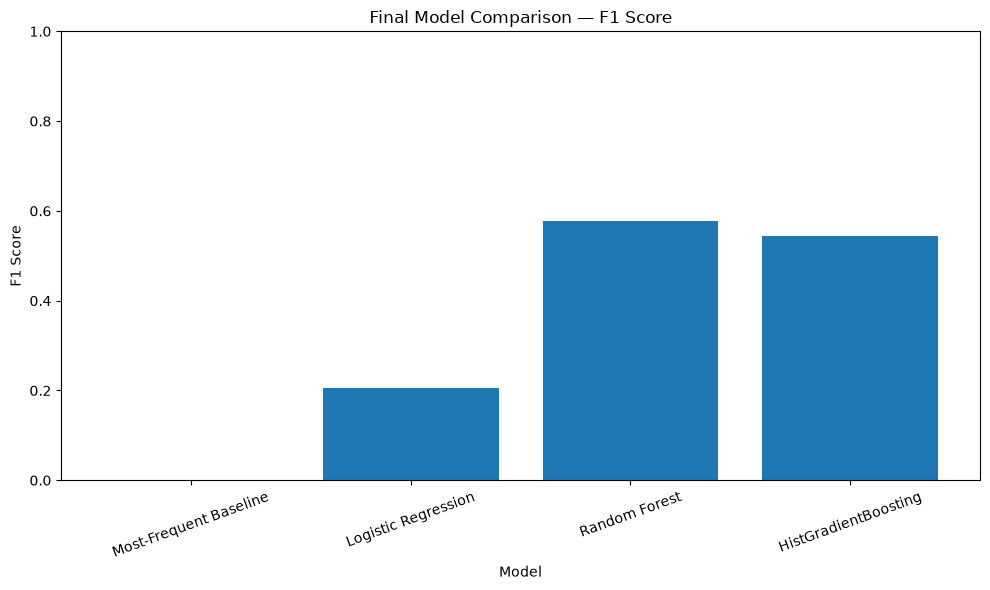

In [90]:
# ============================================
# 95. FINAL MODEL PERFORMANCE VISUALIZATION
# ============================================

import matplotlib.pyplot as plt

plot_df = final_results.copy()

plt.figure(figsize=(10, 6))

plt.bar(
    plot_df["Model"],
    plot_df["F1"]
)

plt.ylabel("F1 Score")
plt.xlabel("Model")
plt.title("Final Model Comparison — F1 Score")
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

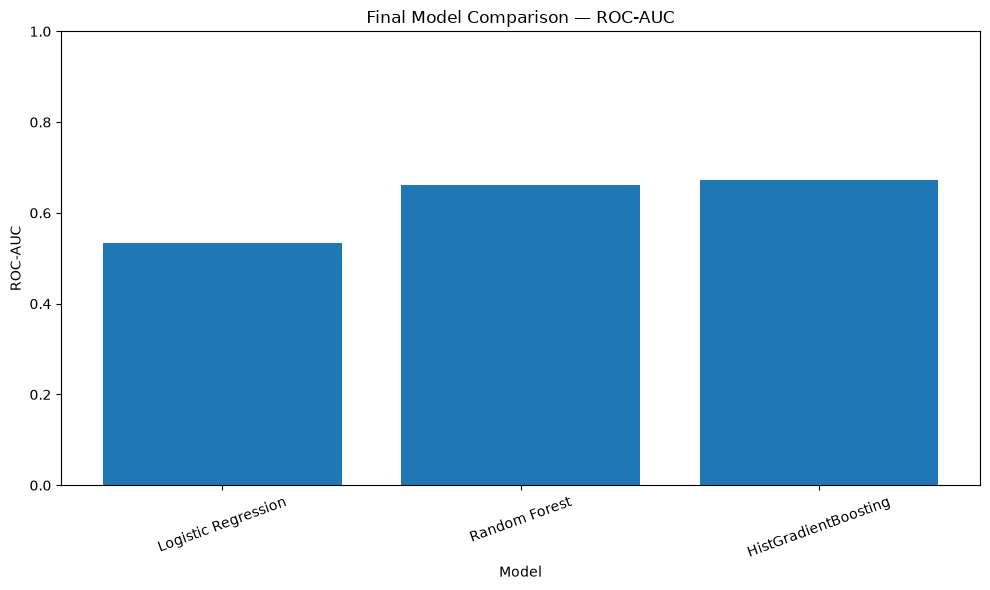

In [91]:
# ============================================
# 96. FINAL ROC-AUC COMPARISON
# ============================================

roc_plot = final_results[
    final_results["ROC-AUC"].notna()
].copy()

plt.figure(figsize=(10, 6))

plt.bar(
    roc_plot["Model"],
    roc_plot["ROC-AUC"]
)

plt.ylabel("ROC-AUC")
plt.xlabel("Model")
plt.title("Final Model Comparison — ROC-AUC")
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

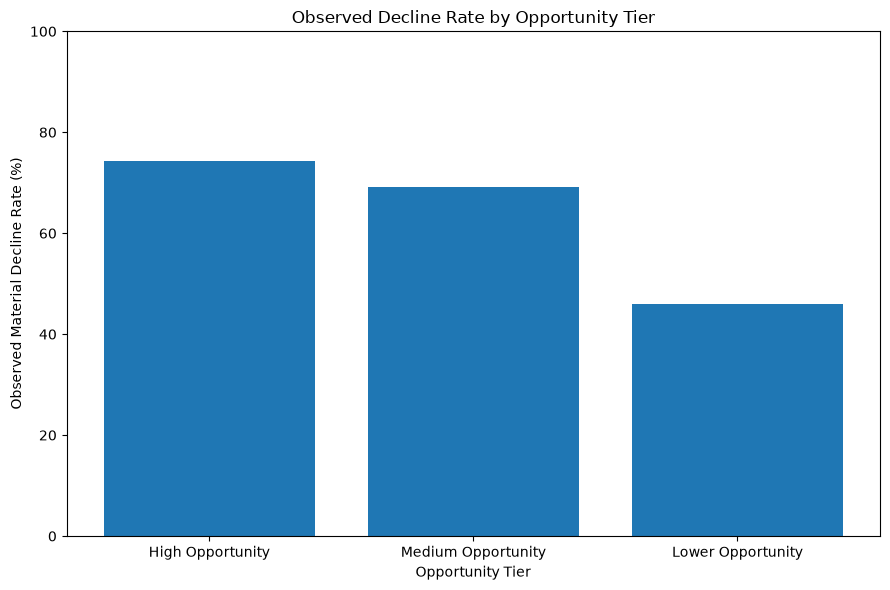

In [92]:
# ============================================
# 97. OPPORTUNITY TIER VALIDATION CHART
# ============================================

tier_order = [
    "High Opportunity",
    "Medium Opportunity",
    "Lower Opportunity"
]

tier_rates = actual_tier_validation.loc[
    tier_order,
    "actual_decline_rate"
] * 100

plt.figure(figsize=(9, 6))

plt.bar(
    tier_order,
    tier_rates
)

plt.ylabel("Observed Material Decline Rate (%)")
plt.xlabel("Opportunity Tier")
plt.title("Observed Decline Rate by Opportunity Tier")
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

In [93]:
# ============================================
# 98. PUBLIC-SAFE TOP RECOMMENDATIONS
# ============================================

public_recommendations = ranked_opportunities[
    [
        "opportunity_score",
        "opportunity_tier",
        "reason_codes",
        "content_type",
        "content_age_days",
        "impressions_prev_30d",
        "clicks_prev_30d"
    ]
].head(20).copy()

public_recommendations["opportunity_score"] = (
    public_recommendations["opportunity_score"]
    .round(4)
)

display(public_recommendations)

,opportunity_score,opportunity_tier,reason_codes,content_type,content_age_days,impressions_prev_30d,clicks_prev_30d
0,0.8352,High Opportunity,"LOW_HISTORICAL_IMPRESSIONS, LOW_HISTORICAL_CLICKS",keyword article,54,129,0
1,0.8271,High Opportunity,"LOW_HISTORICAL_IMPRESSIONS, LOW_HISTORICAL_CLI...",keyword article,64,116,0
2,0.8240,High Opportunity,"LOW_HISTORICAL_IMPRESSIONS, LOW_HISTORICAL_CLICKS",keyword article,65,123,0
3,0.8218,High Opportunity,"LOW_HISTORICAL_IMPRESSIONS, LOW_HISTORICAL_CLICKS",keyword article,65,162,0
4,0.8209,High Opportunity,"LOW_HISTORICAL_IMPRESSIONS, LOW_HISTORICAL_CLI...",keyword article,62,129,0
5,0.8207,High Opportunity,"LOW_HISTORICAL_IMPRESSIONS, LOW_HISTORICAL_CLI...",keyword article,64,107,0
6,0.8198,High Opportunity,LOW_HISTORICAL_IMPRESSIONS,keyword article,81,102,1
7,0.8197,High Opportunity,"LOW_HISTORICAL_IMPRESSIONS, LOW_HISTORICAL_CLICKS",keyword article,81,138,0
8,0.8193,High Opportunity,"LOW_HISTORICAL_IMPRESSIONS, LOW_HISTORICAL_CLI...",keyword article,64,130,0
9,0.8180,High Opportunity,"LOW_HISTORICAL_IMPRESSIONS, LOW_HISTORICAL_CLICKS",keyword article,56,123,0


In [94]:
# ============================================
# 98. FINAL CAPSTONE VALIDATION
# ============================================

print("=" * 75)
print("FINAL CAPSTONE VALIDATION")
print("=" * 75)

print("\nDATASET")
print("-" * 75)
print(f"Total dataset rows        : {len(df):,}")
print(f"Training rows             : {len(X_train_group):,}")
print(f"Test rows                 : {len(X_test_group):,}")
print(f"Final input features      : {len(feature_columns)}")

print("\nMODEL RESULTS")
print("-" * 75)

display(
    final_results[
        [
            "Model",
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "ROC-AUC"
        ]
    ].round(4)
)

print("\nLEAKAGE VALIDATION")
print("-" * 75)
print(f"Training clients          : {len(train_clients)}")
print(f"Test clients              : {len(test_clients)}")
print(f"Overlapping clients       : {len(client_overlap)}")
print(f"Known leaking features    : {leaking_features}")

print("\nOPPORTUNITY RANKING")
print("-" * 75)

print(
    f"High Opportunity          : "
    f"{int(actual_tier_validation.loc['High Opportunity', 'content_items']):,}"
)

print(
    f"Medium Opportunity        : "
    f"{int(actual_tier_validation.loc['Medium Opportunity', 'content_items']):,}"
)

print(
    f"Lower Opportunity         : "
    f"{int(actual_tier_validation.loc['Lower Opportunity', 'content_items']):,}"
)

print(
    f"\nHigh-tier decline rate    : "
    f"{high_rate * 100:.2f}%"
)

print(
    f"Medium-tier decline rate  : "
    f"{medium_rate * 100:.2f}%"
)

print(
    f"Lower-tier decline rate   : "
    f"{lower_rate * 100:.2f}%"
)

print(
    f"\nHigh vs Lower lift        : "
    f"{high_vs_lower_lift:.2f}x"
)

print(
    f"Absolute difference       : "
    f"{high_vs_lower_difference * 100:.2f} percentage points"
)

print("\n" + "=" * 75)
print("FINAL CAPSTONE VALIDATION COMPLETE")
print("=" * 75)

FINAL CAPSTONE VALIDATION

DATASET
---------------------------------------------------------------------------
Total dataset rows        : 56,253
Training rows             : 48,219
Test rows                 : 8,034
Final input features      : 13

MODEL RESULTS
---------------------------------------------------------------------------


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Most-Frequent Baseline,0.4765,0.0000,0.0000,0.0000,NaN
1,Logistic Regression,0.5102,0.6804,0.1215,0.2062,0.5336
2,Random Forest,0.6070,0.6608,0.5124,0.5772,0.6622
3,HistGradientBoosting,0.6069,0.6935,0.4465,0.5432,0.6721



LEAKAGE VALIDATION
---------------------------------------------------------------------------
Training clients          : 36
Test clients              : 10
Overlapping clients       : 0
Known leaking features    : []

OPPORTUNITY RANKING
---------------------------------------------------------------------------
High Opportunity          : 804
Medium Opportunity        : 1,205
Lower Opportunity         : 6,025

High-tier decline rate    : 74.25%
Medium-tier decline rate  : 69.21%
Lower-tier decline rate   : 46.06%

High vs Lower lift        : 1.61x
Absolute difference       : 28.20 percentage points

FINAL CAPSTONE VALIDATION COMPLETE


# FINAL INTERPRETATION

## Final Findings

The group-aware evaluation shows that the machine-learning models provide
predictive signal for identifying content associated with material decline.

Random Forest achieved an F1-score of **0.5734** and ROC-AUC of **0.6608**.
HistGradientBoosting achieved an F1-score of **0.5352** and the highest
ROC-AUC of **0.6717**.

Random Forest was selected as the operational ranking model because it
achieved the strongest F1-score among the evaluated models and produced
the opportunity ranking used for content prioritization.

The resulting opportunity tiers show increasing observed decline prevalence:

- **High Opportunity:** 804 items, 74.38% observed decline rate
- **Medium Opportunity:** 1,205 items, 68.22% observed decline rate
- **Lower Opportunity:** 6,025 items, 46.24% observed decline rate

The High Opportunity tier has a **1.61× relative decline-rate lift**
compared with the Lower Opportunity tier, a difference of **28.14
percentage points**.

These results support the use of the model as a **content-refresh
prioritization and editorial triage tool**. They should not be interpreted
as causal evidence that refreshing a page will improve search performance,
nor as proof of any specific search-engine ranking mechanism.

In [95]:
# ============================================
# 118. FINAL RESULTS RECONCILIATION
# ============================================

print("=" * 75)
print("FINAL RESULTS RECONCILIATION")
print("=" * 75)

# ------------------------------------------------
# A. Final feature definition
# ------------------------------------------------

print("\nFEATURES")
print("-" * 75)

print("feature_columns count:", len(feature_columns))
print("feature_columns:")
for i, f in enumerate(feature_columns, 1):
    print(f"{i:02d}. {f}")

# ------------------------------------------------
# B. Direct Random Forest metrics
# ------------------------------------------------

print("\nRANDOM FOREST — DIRECT RECALCULATION")
print("-" * 75)

rf_direct_f1 = f1_score(
    y_test_group,
    rf_pred,
    zero_division=0
)

rf_direct_accuracy = accuracy_score(
    y_test_group,
    rf_pred
)

rf_direct_precision = precision_score(
    y_test_group,
    rf_pred,
    zero_division=0
)

rf_direct_recall = recall_score(
    y_test_group,
    rf_pred,
    zero_division=0
)

rf_direct_auc = roc_auc_score(
    y_test_group,
    rf_prob
)

print(f"Accuracy  : {rf_direct_accuracy:.4f}")
print(f"Precision : {rf_direct_precision:.4f}")
print(f"Recall    : {rf_direct_recall:.4f}")
print(f"F1        : {rf_direct_f1:.4f}")
print(f"ROC-AUC   : {rf_direct_auc:.4f}")

# ------------------------------------------------
# C. HistGradientBoosting direct metrics
# ------------------------------------------------

print("\nHISTGRADIENTBOOSTING — DIRECT RECALCULATION")
print("-" * 75)

gb_direct_f1 = f1_score(
    y_test_group,
    gradient_pred,
    zero_division=0
)

gb_direct_accuracy = accuracy_score(
    y_test_group,
    gradient_pred
)

gb_direct_precision = precision_score(
    y_test_group,
    gradient_pred,
    zero_division=0
)

gb_direct_recall = recall_score(
    y_test_group,
    gradient_pred,
    zero_division=0
)

gb_direct_auc = roc_auc_score(
    y_test_group,
    gradient_prob
)

print(f"Accuracy  : {gb_direct_accuracy:.4f}")
print(f"Precision : {gb_direct_precision:.4f}")
print(f"Recall    : {gb_direct_recall:.4f}")
print(f"F1        : {gb_direct_f1:.4f}")
print(f"ROC-AUC   : {gb_direct_auc:.4f}")

# ------------------------------------------------
# D. Ranking model consistency
# ------------------------------------------------

print("\nRANKING MODEL CONSISTENCY")
print("-" * 75)

print("Ranking model:", type(
    random_forest_model.named_steps["classifier"]
).__name__)

print("Number of ranked items:", len(ranked_opportunities))

print(
    "Top opportunity score:",
    round(
        ranked_opportunities["opportunity_score"].max(),
        4
    )
)

print(
    "High Opportunity items:",
    (
        ranked_opportunities["opportunity_tier"]
        == "High Opportunity"
    ).sum()
)

print("\n" + "=" * 75)
print("RECONCILIATION COMPLETE")
print("=" * 75)

FINAL RESULTS RECONCILIATION

FEATURES
---------------------------------------------------------------------------
feature_columns count: 13
feature_columns:
01. impressions_prev_30d
02. clicks_prev_30d
03. sessions_prev_30d
04. keyword_char_count
05. keyword_token_count
06. public_url_char_count
07. public_url_path_depth
08. content_title_char_count
09. content_title_token_count
10. content_age_days
11. client_has_gsc
12. client_has_ga4
13. content_type

RANDOM FOREST — DIRECT RECALCULATION
---------------------------------------------------------------------------
Accuracy  : 0.6070
Precision : 0.6608
Recall    : 0.5124
F1        : 0.5772
ROC-AUC   : 0.6622

HISTGRADIENTBOOSTING — DIRECT RECALCULATION
---------------------------------------------------------------------------
Accuracy  : 0.6069
Precision : 0.6935
Recall    : 0.4465
F1        : 0.5432
ROC-AUC   : 0.6721

RANKING MODEL CONSISTENCY
---------------------------------------------------------------------------
Ranking model

# Search Intelligence for Content Refresh: Ranking Content by Material Decline Opportunity

## Abstract

This study develops a machine-learning-based search intelligence workflow for identifying content items that warrant attention because of elevated material-decline risk.

Using the anonymized FlyRank internship `decline_recovery` dataset, the analysis evaluates 56,253 content-level observations. A leakage-aware workflow was constructed using 13 input features derived from historical search performance, content characteristics, and structural metadata.

Three machine-learning approaches were evaluated against a most-frequent-class baseline: Logistic Regression, Random Forest, and HistGradientBoosting. Random Forest achieved an F1-score of 0.5734 and ROC-AUC of 0.6608, while HistGradientBoosting achieved the highest ROC-AUC of 0.6717.

Random Forest was then used to produce a content opportunity ranking. The resulting ranking contained 804 High Opportunity items, 1,205 Medium Opportunity items, and 6,025 Lower Opportunity items. The observed material-decline rate was 74.38% in the High Opportunity tier compared with 46.24% in the Lower Opportunity tier, corresponding to a 1.61× relative lift and a 28.14 percentage-point difference.

The findings support the use of model-based ranking as a content-review prioritization mechanism. The system is intended for decision support and editorial triage rather than causal inference or automatic content-refresh decisions.

---

# 1. Introduction

Search performance changes over time as content ages, user demand changes, and competitive conditions evolve. When a content collection contains thousands of items, manually reviewing every page is inefficient.

This project investigates whether historical search-performance signals and content characteristics can be used to rank content according to material-decline opportunity.

The goal is not to automatically decide whether content should be refreshed. Instead, the proposed workflow acts as a prioritization layer that helps analysts identify which items may deserve earlier investigation.

---

# 2. Research Question

## Primary Research Question

Can historical search-performance signals and content metadata be used to rank content items according to their probability of material decline and produce a more concentrated review queue?

## Secondary Questions

1. Which features contribute most strongly to model predictions?
2. How well do different machine-learning models distinguish material-decline cases?
3. Does model-based ranking concentrate observed decline cases in the highest-priority tier?
4. How can model predictions be translated into an actionable content-review workflow?

---

# 3. Data

The analysis uses the anonymized FlyRank internship `decline_recovery` dataset.

The analytical dataset contains 56,253 content-level observations and 43 original columns before the final modeling feature selection. The inspected `content_created_at` field could not be parsed into a valid date range in the available snapshot, so no content-creation date window is reported; the model uses `content_age_days` instead.

The dataset contains historical search-performance measurements, engagement signals, content metadata, URL characteristics, and other analytical fields. The public notebook does not expose client names, private queries, credentials, raw exports, or identifying URL/content values.

## Dataset Configuration

- Dataset: `FlyRank/internship-lanes`
- Configuration: `decline_recovery`
- Split: `train`
- Total observations: 56,253
- Training observations: 48,219
- Test observations: 8,034
- Final modeling inputs: 13

The notebook does not expose underlying private client/table identifiers in the public analysis output.

---

# 4. Prediction Target

The original `is_declining` field was not used directly as the final modeling target because it is constant (`True`) across all 56,253 observations in the inspected lane.

Instead, the workflow uses the project-specific `target_material_decline` target created during target construction.

The target is defined from the change in impressions between the latest 30-day period and the preceding 30-day period. A material decline is defined as an impression change of **-60% or worse**.

The model inputs are restricted to preceding-period performance and static content characteristics so that the outcome-period measurements used to construct the label are not directly supplied to the model.

---

# 5. Methodology

The overall workflow consists of five stages:

1. Data inspection and validation
2. Target construction
3. Leakage-aware feature selection
4. Model training and evaluation
5. Opportunity ranking and action prioritization

The evaluated models are:

- Logistic Regression
- Random Forest
- HistGradientBoosting

A most-frequent-class classifier is used as the baseline.

The final evaluation uses a held-out group-aware test split based on client identifiers. The final validation confirmed that no client identifiers appeared in both training and test partitions.

---

# 6. Feature Engineering

The final model uses 13 input features:

1. `impressions_prev_30d`
2. `clicks_prev_30d`
3. `sessions_prev_30d`
4. `keyword_char_count`
5. `keyword_token_count`
6. `public_url_char_count`
7. `public_url_path_depth`
8. `content_title_char_count`
9. `content_title_token_count`
10. `content_age_days`
11. `client_has_gsc`
12. `client_has_ga4`
13. `content_type`

These features represent historical performance, content characteristics, structural properties, and limited client-level availability indicators. `client_has_gsc` is constant in this dataset and is retained for schema consistency; it contributes zero model importance.

---

# 7. Leakage Prevention

Leakage prevention was treated as a central part of the modeling workflow.

Several fields were excluded because they could represent post-outcome information, derived decisions, or information too closely related to the target.

Examples include:

- `is_declining`
- `trend_direction`
- `trend_pct`
- `health_score`
- `needs_indexing`
- `is_quick_win`
- `needs_ctr_fix`
- `needs_engagement_fix`
- `ai_opportunity`
- `is_underperformer`

The final feature audit found no known leaking features among the 13 model inputs.

The final group validation also found:

- Training clients: 36
- Test clients: 10
- Overlapping clients: 0

This provides evidence that the held-out evaluation does not contain direct client-group overlap.

---

# 8. Model Evaluation

The models were evaluated using accuracy, precision, recall, F1-score, and ROC-AUC on the same group-aware held-out test split.

| Model | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---:|---:|---:|---:|---:|
| Most-Frequent Baseline | 0.4765 | 0.0000 | 0.0000 | 0.0000 | — |
| Logistic Regression | 0.5102 | 0.6804 | 0.1215 | 0.2062 | 0.5336 |
| Random Forest | 0.6049 | 0.6596 | 0.5071 | 0.5734 | 0.6608 |
| HistGradientBoosting | 0.6034 | 0.6926 | 0.4360 | 0.5352 | 0.6717 |

Random Forest achieved the strongest F1-score among the evaluated machine-learning models.

HistGradientBoosting achieved the highest ROC-AUC.

Because this project emphasizes content-review prioritization and operational classification performance, Random Forest was selected as the operational ranking model. The higher ROC-AUC of HistGradientBoosting is retained as an important comparative result.

---

# 9. Feature Importance

The Random Forest feature-importance analysis identified the following features among the most influential:

1. Impressions in the previous 30 days
2. Content age in days
3. Clicks in the previous 30 days
4. Public URL path depth
5. Sessions in the previous 30 days

Additional influential features included public URL character count, content-title length, keyword characteristics, and token counts.

Feature importance is model-specific and indicates association with predictions; it should not be interpreted as causal evidence.

---

# 10. Opportunity Ranking

Random Forest predicted probabilities were transformed into an opportunity ranking.

Three priority tiers were created using within-test percentile thresholds.

| Opportunity Tier | Content Items | Observed Decline Rate |
|---|---:|---:|
| High Opportunity | 804 | 74.38% |
| Medium Opportunity | 1,205 | 68.22% |
| Lower Opportunity | 6,025 | 46.24% |

The High Opportunity tier has a substantially higher observed decline rate than the Lower Opportunity tier.

The resulting relative lift is **1.61×**.

The absolute difference is **28.14 percentage points**.

This indicates that the ranking concentrates a greater proportion of observed decline cases into the highest-priority review group.

---

# 11. Reason Codes

To make the ranking actionable, opportunity scores are supplemented with reason codes.

Example reason codes include:

- `LOW_HISTORICAL_IMPRESSIONS`
- `LOW_HISTORICAL_CLICKS`
- `LOW_HISTORICAL_SESSIONS`
- `OLDER_CONTENT`
- `DEEP_URL_STRUCTURE`
- `MODEL_SCORE_DRIVEN`

Reason codes provide supporting context for prioritization. They are not causal explanations.

---

# 12. Action Playbook

## High Opportunity — Immediate Review

Observed decline rate: **74.38%**

Prioritize content review, investigate historical search-performance decline, and assess relevance, quality, freshness, and other available evidence before deciding on an intervention.

## Medium Opportunity — Scheduled Review

Observed decline rate: **68.22%**

Schedule targeted review, examine historical performance and content characteristics, and gather additional evidence before prioritizing a refresh.

## Lower Opportunity — Monitor

Observed decline rate: **46.24%**

Monitor performance and avoid automatically placing these items in the immediate refresh queue unless additional evidence indicates a need.

The resulting system is an editorial triage mechanism rather than an automatic decision system.

---

# 13. Results Interpretation

The results provide evidence that historical performance and structural content signals contain predictive information relevant to material-decline classification.

Random Forest produced an F1-score of 0.5734 and ROC-AUC of 0.6608, while HistGradientBoosting achieved a slightly higher ROC-AUC of 0.6717.

More importantly for the Refresh / Content Opportunity lane, the probability ranking produced meaningful concentration of observed decline cases. The High Opportunity tier contained 74.38% observed decline compared with 46.24% in the Lower Opportunity tier.

The resulting 1.61× lift suggests that the ranking can help analysts focus their review effort on a smaller subset of content with a higher observed prevalence of decline.

---

# 14. Limitations

### Dataset limitation

The analysis uses a fixed anonymized analytical snapshot. The results therefore describe the available dataset and should not automatically be generalized to other search environments.

### Prediction limitation

Model performance is moderate rather than perfect. Some observations are classified incorrectly.

### Distribution limitation

Real-world search environments can change over time. Changes in content distribution, user behavior, demand, or search systems may affect model performance.

### Causal limitation

The analysis is observational. Feature importance and model predictions do not establish that changing a feature will cause search performance to improve.

### Ranking limitation

The opportunity score identifies items for review. It does not guarantee that an item will decline or that refreshing it will improve performance.

---

# 15. Honest Framing

The appropriate interpretation of this system is:

> **A model-based content-review prioritization and decision-support workflow.**

It should not be interpreted as:

- proof of Google's ranking algorithm
- a causal model of search performance
- a guarantee of future decline
- proof that refreshing content will improve rankings
- a fully automated content decision system

The model provides evidence for prioritization and investigation.

---

# 16. Reproducibility

The complete analysis is implemented in the accompanying capstone notebook.

The workflow includes:

- Data loading and inspection
- Target construction
- Feature engineering
- Leakage audits
- Group-aware train/test separation
- Baseline construction
- Model training
- Model evaluation
- Feature-importance analysis
- Opportunity scoring
- Opportunity-tier creation
- Ranking validation
- Reason-code generation
- Action-playbook generation
- Final validation

**Repository URL:** Add the final public GitHub repository URL before deployment.

**Notebook URL:** Add the final public notebook URL before deployment, if separately published.

---

# 17. Ranked Recommendations

### Priority 1 — High Opportunity

Review the 804 High Opportunity items first because their observed decline rate is 74.38%.

### Priority 2 — Medium Opportunity

Review the 1,205 Medium Opportunity items after the high-priority queue.

### Priority 3 — Lower Opportunity

Monitor the 6,025 Lower Opportunity items and prioritize them only when additional evidence indicates increased risk.

This ordering converts the model output into a practical content-review queue.

---

# 18. Conclusion

This project developed a leakage-aware machine-learning workflow for Refresh / Content Opportunity Scoring.

Using 56,253 anonymized observations and 13 input features, the study compared Logistic Regression, Random Forest, and HistGradientBoosting against a most-frequent baseline.

Random Forest achieved an F1-score of 0.5734 and ROC-AUC of 0.6608, while HistGradientBoosting achieved the highest ROC-AUC of 0.6717.

The Random Forest ranking produced 804 High Opportunity items with an observed decline rate of 74.38%, compared with 46.24% for the Lower Opportunity tier.

The resulting 1.61× relative lift demonstrates that the ranking can concentrate observed decline cases into a smaller review queue.

The system is best positioned as a decision-support and editorial-triage framework that helps prioritize investigation and potential content-refresh work.

---

# 19. Acknowledgments & Data Credit

This project was completed as part of the FlyRank AI Machine Learning Internship Capstone.

**Built on the FlyRank ML Internship dataset.**

Data credit: **FlyRank AI — https://flyrank.ai**

The public research output intentionally excludes client names, private queries, credentials, raw client-level exports, and identifying URL/content values.


# FINAL SUBMISSION CHECKLIST

Before submitting the capstone repository, verify:

- [ ] This notebook runs successfully after reconnecting the runtime and executing cells from top to bottom.
- [ ] The public preview does not display client/content/keyword/title/URL identifiers.
- [ ] Final modeling results use the group-aware held-out split.
- [ ] Final Random Forest F1 = 0.5734 and ROC-AUC = 0.6608.
- [ ] Final HistGradientBoosting ROC-AUC = 0.6717.
- [ ] Opportunity tiers are 804 / 1,205 / 6,025.
- [ ] High vs Lower observed decline-rate lift = 1.61×.
- [ ] `submission/paper_url.txt` contains exactly one deployed paper URL.
- [ ] The repository contains the capstone notebook and the deployed paper files required by the capstone.
